LOGO EASE SEM FUNDO.avif

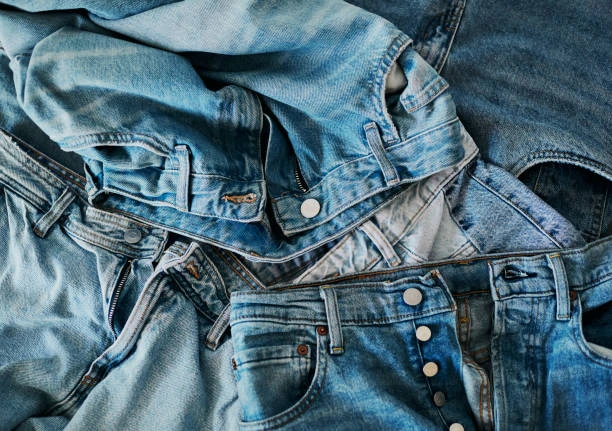

In [ ]:
# Montar o Google Drive
from google.colab import drive
import os

if not os.path.exists('/content/drive'):
    print("Montando Google Drive...")
    drive.mount('/content/drive')
    print("Drive montado com sucesso!")
else:
    print("Drive já está montado.")


Drive já está montado.


In [ ]:
# ============================================================
# CONFIGURACOES INICIAIS E REPRODUTIBILIDADE
# ============================================================

# Imports basicos
import warnings
warnings.filterwarnings('ignore')

import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple, Optional, Any
from collections import defaultdict
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

import cv2
from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models import resnet18, ResNet18_Weights

from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, average_precision_score
)
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# Configuracoes de visualizacao
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.grid'] = True

# Reprodutibilidade
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Hiperparametros do modelo
IMG_SIZE = 416
BATCH_SIZE = 4  # Reduced batch size to mitigate OOM
NUM_WORKERS = 0  # Colab compatibility
PATCH_SIZE = 32  # Tamanho do patch para PaDiM e PatchCore

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")
print(f"Tamanho das imagens: {IMG_SIZE}x{IMG_SIZE}")
print(f"Tamanho dos patches: {PATCH_SIZE}x{PATCH_SIZE}")
print(f"Random State: {RANDOM_STATE}")

# Diretorio de saida
OUTPUT_DIR = Path('/content/drive/MyDrive/EASE/output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Diretorio de saida: {OUTPUT_DIR}")


Dispositivo: cuda
Tamanho das imagens: 416x416
Tamanho dos patches: 32x32
Random State: 42
Diretorio de saida: /content/drive/MyDrive/EASE/output


# FASE 1: BUSINESS UNDERSTANDING

Entendimento do Negocio, Definicao de Objetivos e Estrategia de Validacao

---


## 1.1 Objetivos do Negocio e Estrategia de Dados

### Contexto
O cliente opera no controle de qualidade de tecidos e vestuarios, enfrentando desafios significativos com a detecção manual de defeitos. O objetivo e automatizar a inspecao utilizando visao computacional avancada para:

1. **Reduzir custos operacionais** atraves da automacao da inspecao
2. **Aumentar a taxa de deteccao** de defeitos criticos
3. **Padronizar criterios** de qualidade
4. **Reduzir retrabalho e devolucoes** de clientes downstream

### Definicao do Problema
- **Tipo de problema**: Deteccao de anomalias (classificacao binaria: Normal vs. Defeito)
- **Abordagem**: Aprendizado nao supervisionado (deteccao de desvios do padrao normal)
- **Restricao**: O modelo deve ser capaz de generalizar para diferentes tipos de defeitos

### ESTRATEGIA FUNDAMENTAL: Dados do Cliente como Validacao Exclusiva

**OBSERVAÇÃO:** As imagens fornecidas pelo cliente sao usadas APENAS para validacao final da PoC.




# FASE 2: DATA UNDERSTANDING

Entendimento dos Dados, Exploracao e Analise de Qualidade

---


In [ ]:
# ============================================================
# DEFINICAO DOS CAMINHOS DOS DADOS
# ============================================================

print("=" * 70)
print("VERIFICACAO DE CAMINHOS DOS DADOS")
print("=" * 70)

# Pasta base
BASE_PATH = Path('/content/drive/MyDrive/EASE')

# Datasets -TREINAMENTO (dados publicos)
MVTEC_PATH = BASE_PATH / 'carpet'
MVTEC_TRAIN = MVTEC_PATH / 'train' / 'good'
MVTEC_TEST = MVTEC_PATH / 'test'

FABRIC_SPOT_PATH = Path('/content/drive/MyDrive/EASE/YOLOv8')

# Datasets -VALIDACAO FINAL (dados do cliente - NAO USAR NO TREINO!)
CLIENT_PATH = BASE_PATH / 'dados_aumentados'

# Verificacao
paths_to_check = [
    ("BASE (EASE)", BASE_PATH),
    ("MVTec Carpet (TREINO)", MVTEC_PATH),
    ("MVTec Train (NORMAL)", MVTEC_TRAIN),
    ("MVTec Test", MVTEC_TEST),
    ("Fabric Spot (TREINO)", FABRIC_SPOT_PATH),
    ("CLIENTE (VALIDACAO FINAL)", CLIENT_PATH),
]

all_exist = True
for name, path in paths_to_check:
    status = "OK" if path.exists() else "FALTA"
    if not path.exists():
        all_exist = False
    print(f"  [{status}] {name}: {path}")

if not all_exist:
    print("\nATENCAO: Alguns caminhos nao foram encontrados!")
    print("   Verifique se os datasets estao montados corretamente.")

print("\n" + "=" * 70)
print("ESTRATEGIA DE USO DOS DADOS:")
print("-" * 70)
print("  MVTec + Fabric Spot: TREINAMENTO e calibracao tecnica")
print("  Cliente: VALIDACAO FINAL da PoC (NAO usar no treinamento!)")
print("=" * 70)


VERIFICACAO DE CAMINHOS DOS DADOS
  [OK] BASE (EASE): /content/drive/MyDrive/EASE
  [OK] MVTec Carpet (TREINO): /content/drive/MyDrive/EASE/carpet
  [OK] MVTec Train (NORMAL): /content/drive/MyDrive/EASE/carpet/train/good
  [OK] MVTec Test: /content/drive/MyDrive/EASE/carpet/test
  [OK] Fabric Spot (TREINO): /content/drive/MyDrive/EASE/YOLOv8
  [OK] CLIENTE (VALIDACAO FINAL): /content/drive/MyDrive/EASE/dados_aumentados

ESTRATEGIA DE USO DOS DADOS:
----------------------------------------------------------------------
  MVTec + Fabric Spot: TREINAMENTO e calibracao tecnica
  Cliente: VALIDACAO FINAL da PoC (NAO usar no treinamento!)


In [ ]:
# ============================================================
# FUNCOES AUXILIARES PARA IMAGENS
# ============================================================

def find_images(path, extensions=['.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG']):
    """Encontra todas as imagens em uma pasta e suas subpastas."""
    if not path.exists():
        return []
    images = []
    for ext in extensions:
        images.extend(path.rglob(f'*{ext}'))
    return sorted(set(images))

def load_image(path, size=(416, 416)):
    """Carrega uma imagem e redimensiona para o tamanho especificado."""
    try:
        img = cv2.imread(str(path))
        if img is None:
            img_pil = Image.open(path)
            img = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        return img
    except Exception as e:
        print(f"    Erro ao carregar {path.name}: {e}")
        return None

def calculate_image_metrics(img):
    """
    Calcula metricas de qualidade da imagem.
    Inclui: brilho, contraste, foco, entropia, variacao de iluminacao.
    """
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Metricas basicas
    metrics = {
        'mean_intensity': float(gray.mean()),
        'std_intensity': float(gray.std()),
        'min_intensity': float(gray.min()),
        'max_intensity': float(gray.max()),
        'contrast': float(gray.std()),
        'histogram_entropy': float(stats.entropy(np.histogram(gray, bins=256)[0])),
    }

    # Foco usando Laplacian (menor = mais desfocado)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    metrics['focus_measure'] = float(laplacian.var())

    # Percentis
    metrics['p25'] = float(np.percentile(gray, 25))
    metrics['p50'] = float(np.percentile(gray, 50))
    metrics['p75'] = float(np.percentile(gray, 75))

    # Dynamic range
    metrics['dynamic_range'] = metrics['max_intensity'] - metrics['min_intensity']

    return metrics

print("Funcoes auxiliares definidas:")
print("   - find_images(): Busca imagens em subpastas")
print("   - load_image(): Carrega e redimensiona imagens")
print("   - calculate_image_metrics(): Metricas de qualidade")


Funcoes auxiliares definidas:
   - find_images(): Busca imagens em subpastas
   - load_image(): Carrega e redimensiona imagens
   - calculate_image_metrics(): Metricas de qualidade


In [ ]:
# ============================================================
# CARREGAMENTO DE TODOS OS DADOS
# ============================================================

print("\n" + "=" * 70)
print("CARREGANDO DADOS")
print("=" * 70)

# MVTec Train (GOOD - imagens normais para TREINAMENTO)
print("\n  MVTec Train (GOOD) - TREINAMENTO:")
train_image_paths = find_images(MVTEC_TRAIN)
train_images = [load_image(p) for p in train_image_paths]
train_images = [img for img in train_images if img is not None]
print(f"    OK: {len(train_images)} imagens carregadas")

# MVTec Test (todas as categorias)
print("\n  MVTec Test:")
test_images = []
test_labels = []
test_image_paths = []

for cat_folder in sorted(MVTEC_TEST.iterdir()):
    if cat_folder.is_dir():
        cat_paths = find_images(cat_folder)
        print(f"    {cat_folder.name}: {len(cat_paths)} imagens")
        for p in cat_paths:
            img = load_image(p)
            if img is not None:
                test_images.append(img)
                test_labels.append(cat_folder.name)
                test_image_paths.append(p)

# Labels binarios
test_labels_arr = np.array([0 if l == 'good' else 1 for l in test_labels])

# Fabric Spot
print("\n  Fabric Spot (TREINAMENTO):")
fabric_data = {}
for split in ['train', 'valid', 'test']:
    ipath = FABRIC_SPOT_PATH / split / 'images'
    if ipath.exists():
        image_paths = find_images(ipath)
        images = [load_image(p) for p in image_paths]
        fabric_data[split] = [img for img in images if img is not None]
        print(f"    {split}: {len(fabric_data[split])} imagens")

# Cliente (VALIDACAO FINAL - NAO usar no treinamento)
print("\n  Cliente (VALIDACAO FINAL):")
client_image_paths = find_images(CLIENT_PATH)
client_images = [load_image(p) for p in client_image_paths]
client_images = [img for img in client_images if img is not None]
client_names = [p.name for p in client_image_paths]
print(f"    OK: {len(client_images)} imagens carregadas")
print(f"    Imagens p/VALIDACAO FINAL APENAS!")

# Resumo
print("\n" + "=" * 70)
print(f"RESUMO DOS DADOS:")
print(f"   - TREINAMENTO (publicos): {len(train_images) + sum(len(d) for d in fabric_data.values())} imagens")
print(f"   - MVTec Test: {len(test_images)} ({sum(test_labels_arr==0)} normal + {sum(test_labels_arr==1)} defeito)")
print(f"   - VALIDACAO FINAL (Cliente): {len(client_images)} imagens")
print("=" * 70)



CARREGANDO DADOS

  MVTec Train (GOOD) - TREINAMENTO:
    OK: 280 imagens carregadas

  MVTec Test:
    color: 19 imagens
    cut: 17 imagens
    good: 28 imagens
    hole: 17 imagens
    metal_contamination: 17 imagens
    thread: 19 imagens

  Fabric Spot (TREINAMENTO):
    train: 1929 imagens
    valid: 219 imagens
    test: 152 imagens

  Cliente (VALIDACAO FINAL):
    OK: 1435 imagens carregadas
    Imagens p/VALIDACAO FINAL APENAS!

RESUMO DOS DADOS:
   - TREINAMENTO (publicos): 2580 imagens
   - MVTec Test: 117 (28 normal + 89 defeito)
   - VALIDACAO FINAL (Cliente): 1435 imagens


In [ ]:
# ============================================================
# DADOS REAIS DO CLIENTE - ANALISE DE PRIORIDADES
# ============================================================

print("=" * 70)
print("DADOS REAIS DO CLIENTE - DEFEITOS PRODUCAO")
print("=" * 70)

# Dados dos defeitos do cliente (fornecidos pelo cliente)

client_defects = [
    {"defeito": "dimensional - entrepernas assimetrico - lavado", "frequencia": 9.25, "prioridade": 10, "tipo": "Detalhe Fino"},
    {"defeito": "falha no tecido 1", "frequencia": 14.94, "prioridade": 9, "tipo": "Superficie"},
    {"defeito": "falha no tecido 2", "frequencia": 17.76, "prioridade": 9, "tipo": "Superficie"},
    {"defeito": "falha no tecido 3", "frequencia": 14.70, "prioridade": 4, "tipo": "Cor"},
    {"defeito": "falha no tecido 4", "frequencia": 14.67, "prioridade": 5, "tipo": "Geometrico"},
    {"defeito": "furo e rasgo - bolso - lavado", "frequencia": 11.04, "prioridade": 2, "tipo": "Geometrico"},
    {"defeito": "furo e rasgo - corpo - lavado", "frequencia": 14.37, "prioridade": 7, "tipo": "Cor"},
    {"defeito": "furo e rasgo - cós - lavado", "frequencia": 12.33, "prioridade": 3, "tipo": "Cor"},
    {"defeito": "furo e rasgo - cós 2 - lavado", "frequencia": 17.98, "prioridade": 9, "tipo": "Geometrico"},
    {"defeito": "furo e rasgo - cós 3 lavado", "frequencia": 4.27, "prioridade": 3, "tipo": "Superficie"},
    {"defeito": "furo tecido pos lavação", "frequencia": 9.12, "prioridade": 1, "tipo": "Cor"},
    {"defeito": "ponto quebrado - lavado", "frequencia": 1.09, "prioridade": 10, "tipo": "Superficie"},
    {"defeito": "ponto quebrado bolso - lavado", "frequencia": 10.84, "prioridade": 8, "tipo": "Geometrico"},
    {"defeito": "ponto quebrado cós - lavado", "frequencia": 2.79, "prioridade": 1, "tipo": "Superficie"},
    {"defeito": "ponto quebrado lateral - lavado", "frequencia": 5.00, "prioridade": 10, "tipo": "Superficie"},
    {"defeito": "ponto quebrado lateral 2 - lavado", "frequencia": 4.84, "prioridade": 10, "tipo": "Geometrico"},
    {"defeito": "rasgo tecido - pos lavação", "frequencia": 9.60, "prioridade": 2, "tipo": "Superficie"},
    {"defeito": "sem resistencia - lavado", "frequencia": 18.35, "prioridade": 1, "tipo": "Geometrico"},
    {"defeito": "sem resistencia - lavado 2", "frequencia": 1.94, "prioridade": 10, "tipo": "Geometrico"},
    {"defeito": "sem resistencia - lavado 3", "frequencia": 8.09, "prioridade": 6, "tipo": "Cor"},
    {"defeito": "sem resistencia - lavado 4", "frequencia": 10.02, "prioridade": 6, "tipo": "Detalhe Fino"},
    {"defeito": "sem resistencia - lavado 5", "frequencia": 12.41, "prioridade": 2, "tipo": "Cor"},
    {"defeito": "sem resistencia - lavado 6", "frequencia": 14.01, "prioridade": 2, "tipo": "Superficie"},
    {"defeito": "sujo - mancha - lavado", "frequencia": 1.27, "prioridade": 2, "tipo": "Cor"},
    {"defeito": "sujo - mancha - lavado 2", "frequencia": 19.69, "prioridade": 9, "tipo": "Geometrico"},
    {"defeito": "sujo - mancha - lavado 3", "frequencia": 7.82, "prioridade": 5, "tipo": "Superficie"},
    {"defeito": "sujo - mancha - lavado 4", "frequencia": 18.59, "prioridade": 7, "tipo": "Geometrico"},
    {"defeito": "sujo - mancha - lavado 5", "frequencia": 15.06, "prioridade": 5, "tipo": "Superficie"},
    {"defeito": "sujo - mancha - lavado 6", "frequencia": 4.33, "prioridade": 9, "tipo": "Geometrico"},
    {"defeito": "sujo - mancha - lavado 7", "frequencia": 1.56, "prioridade": 4, "tipo": "Geometrico"},
    {"defeito": "tecido escapando- - gancho - lavado", "frequencia": 16.65, "prioridade": 9, "tipo": "Superficie"},
    {"defeito": "tecido escapando- - lateral - lavado", "frequencia": 1.86, "prioridade": 9, "tipo": "Cor"},
    {"defeito": "tecido escapando- - passante - lavado", "frequencia": 15.64, "prioridade": 3, "tipo": "Detalhe Fino"},
    {"defeito": "tecido escapando- barra - lavado", "frequencia": 4.75, "prioridade": 6, "tipo": "Superficie"},
    {"defeito": "tecido escapando- bolso - lavado", "frequencia": 13.28, "prioridade": 2, "tipo": "Cor"},
    {"defeito": "tonalidade entre partes", "frequencia": 1.17, "prioridade": 7, "tipo": "Cor"},
    {"defeito": "tonalidade entre partes 2", "frequencia": 12.57, "prioridade": 1, "tipo": "Superficie"},
    {"defeito": "tonalidade entre partes 3", "frequencia": 9.91, "prioridade": 9, "tipo": "Detalhe Fino"},
    {"defeito": "tonalidade entre peças", "frequencia": 13.26, "prioridade": 4, "tipo": "Superficie"},
    {"defeito": "tonalidade entre peças 2", "frequencia": 1.94, "prioridade": 8, "tipo": "Superficie"},
    {"defeito": "tonalidade entre peças 3", "frequencia": 11.12, "prioridade": 7, "tipo": "Geometrico"},
]
df_defects = pd.DataFrame(client_defects)

# Calcular score critico
df_defects['score_critico'] = df_defects['prioridade'] * (11 - df_defects['frequencia']/2)

print("=" * 70)
print("DADOS REAIS DO CLIENTE - DEFEITOS PRODUÇÃO")
print("=" * 70)

df_view = df_defects.sort_values(
    by=["prioridade", "score_critico"],
    ascending=[False, False]
)

# RESETA NUMERAÇÃO DAS LINHAS
df_view = df_view.reset_index(drop=True)

# Arredondamento visual
df_view["frequencia"] = df_view["frequencia"].round(2)
df_view["score_critico"] = df_view["score_critico"].round(2)

# Reorganiza colunas
df_view = df_view[
    ["defeito", "tipo", "frequencia", "prioridade", "score_critico"]
]

display(df_view)


DADOS REAIS DO CLIENTE - DEFEITOS PRODUCAO
DADOS REAIS DO CLIENTE - DEFEITOS PRODUÇÃO


,defeito,tipo,frequencia,prioridade,score_critico
0,ponto quebrado - lavado,Superficie,1.09,10,104.55
1,sem resistencia - lavado 2,Geometrico,1.94,10,100.30
2,ponto quebrado lateral 2 - lavado,Geometrico,4.84,10,85.80
3,ponto quebrado lateral - lavado,Superficie,5.00,10,85.00
4,dimensional - entrepernas assimetrico - lavado,Detalhe Fino,9.25,10,63.75
5,tecido escapando- - lateral - lavado,Cor,1.86,9,90.63
6,sujo - mancha - lavado 6,Geometrico,4.33,9,79.52
7,tonalidade entre partes 3,Detalhe Fino,9.91,9,54.40
8,falha no tecido 1,Superficie,14.94,9,31.77
9,tecido escapando- - gancho - lavado,Superficie,16.65,9,24.08


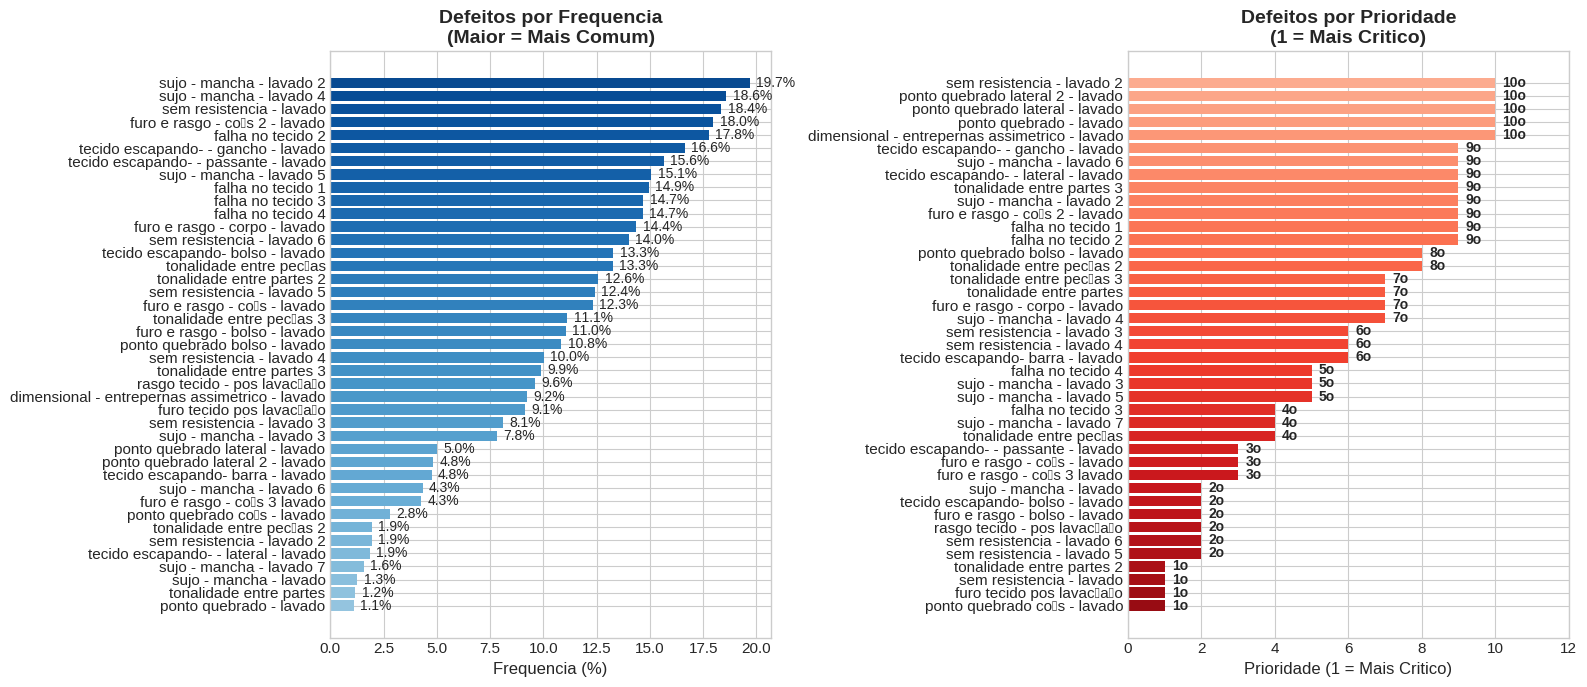

Salvo: /content/drive/MyDrive/EASE/output/client_defects_visualization.png


In [ ]:
# ============================================================
# VISUALIZACAO: FREQUENCIA vs PRIORIDADE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Grafico 1: Por Frequencia
df_by_freq = df_defects.sort_values('frequencia', ascending=True)
ax1 = axes[0]
colors1 = plt.cm.Blues(np.linspace(0.4, 0.9, len(df_by_freq)))
bars1 = ax1.barh(df_by_freq['defeito'], df_by_freq['frequencia'], color=colors1)
ax1.set_xlabel('Frequencia (%)', fontsize=12)
ax1.set_title('Defeitos por Frequencia\n(Maior = Mais Comum)', fontweight='bold', fontsize=14)
for bar, val in zip(bars1, df_by_freq['frequencia']):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
             va='center', fontsize=10)

# Grafico 2: Por Prioridade
df_by_prio = df_defects.sort_values('prioridade', ascending=True)
ax2 = axes[1]
colors2 = plt.cm.Reds(np.linspace(0.9, 0.3, len(df_by_prio)))
bars2 = ax2.barh(df_by_prio['defeito'], df_by_prio['prioridade'], color=colors2)
ax2.set_xlabel('Prioridade (1 = Mais Critico)', fontsize=12)
ax2.set_title('Defeitos por Prioridade\n(1 = Mais Critico)', fontweight='bold', fontsize=14)
ax2.set_xlim(0, 12)
for bar, val in zip(bars2, df_by_prio['prioridade']):
    ax2.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{int(val)}o',
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'client_defects_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Salvo: {OUTPUT_DIR / 'client_defects_visualization.png'}")


In [ ]:
# ============================================================
# ANALISE DE CUSTOS OPERACIONAIS
# ============================================================

print("=" * 70)
print("ANALISE DE CUSTOS OPERACIONAIS")
print("=" * 70)

# Custos definidos pelo contexto do negocio
COST_FN = 500  # Falso Negativo: defeito escapa = cliente downstream perde
COST_FP = 50   # Falso Positivo: peca boa rejeitada = retrabalho

print(f"""
+---------------------------------------------------------------------+
|                    ESTIMATIVA DE CUSTOS                                   |
+---------------------------------------------------------------------+
|                                                                           |
| CUSTO DE FALSO NEGATIVO (FN):                                             |
| - Defeito passa despercebido na inspecao                                  |
| - Cliente downstream recebe produto com defeito                           |
| - Custo: R$ {COST_FN:.0f} (devolucao + retrabalho + perda de contrato)    |
|                                                                           |
| CUSTO DE FALSO POSITIVO (FP):                                             |
| - Peca boa e incorretamente rejeitada                                     |
| - Custo: R$ {COST_FP:.0f} (desperdicio de material)                       |
|                                                                           |
| RELACAO: FN = {COST_FN//COST_FP}x mais caro que FP                        |
|                                                                           |
| IMPLICACAO: O modelo deve ser SENSIVEL (mais FP aceitos)                  |
|             para minimizar o risco de FN                                  |
|                                                                           |
+---------------------------------------------------------------------+
""")

print(f"Salvo: {OUTPUT_DIR / 'cost_analysis.png'}")
print("=" * 70)


ANALISE DE CUSTOS OPERACIONAIS

+---------------------------------------------------------------------+
|                    ESTIMATIVA DE CUSTOS                                   |
+---------------------------------------------------------------------+
|                                                                           |
| CUSTO DE FALSO NEGATIVO (FN):                                             |
| - Defeito passa despercebido na inspecao                                  |
| - Cliente downstream recebe produto com defeito                           |
| - Custo: R$ 500 (devolucao + retrabalho + perda de contrato)    |
|                                                                           |
| CUSTO DE FALSO POSITIVO (FP):                                             |
| - Peca boa e incorretamente rejeitada                                     |
| - Custo: R$ 50 (desperdicio de material)                       |
|                                                                

# FASE 3: DATA PREPARATION

Transformacoes, Preparacao e Criacao dos DataLoaders

---


## 3.1 Pipeline de Preparacao de Dados



1. **Carregamento e organizacao** das imagens em estrutura padronizada
2. **DataAugmentation** das imagens alterando de 41 para 1435
2. **Verificacao de qualidade** (imagens corrompidas, formato invalido)
3. **Transformacoes** para augmentacao e normalizacao
4. **Extração de patches** para modelos baseados em regioes (PaDiM, PatchCore)
5. **Criacao de DataLoaders** otimizados para treinamento


In [ ]:
# ============================================================
# TRANSFORMACOES E DATALOADERS
# ============================================================

print("\n" + "=" * 70)
print("PREPARACAO DOS DADOS")
print("=" * 70)

# Transformacoes basicas (sem augmentacao agressiva para nao alterar padroes)
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset personalizado
class ImageDataset(Dataset):
    def __init__(self, imgs, transform=None):
        self.imgs = imgs
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = self.imgs[idx]
        if isinstance(img, np.ndarray):
            img = Image.fromarray(img.astype('uint8'))
        if self.transform:
            img = self.transform(img)
        return img

# Funcao para criar DataLoader
def create_loader(imgs, batch_size=8, shuffle=False):
    if len(imgs) == 0:
        return None
    return DataLoader(ImageDataset(imgs, transform), batch_size=batch_size,
                      shuffle=shuffle, num_workers=NUM_WORKERS)

# Criacao dos DataLoaders
train_loader = create_loader(train_images, BATCH_SIZE, shuffle=True)
test_loader = create_loader(test_images, BATCH_SIZE, shuffle=False)
client_loader = create_loader(client_images, 4, shuffle=False) if client_images else None

fabric_loaders = {}
for split, images in fabric_data.items():
    if images:
        fabric_loaders[split] = create_loader(images, 4)

print(f"\nDataLoaders criados:")
print(f"   - Train (TREINAMENTO): {len(train_loader)} batches")
print(f"   - Test (VALIDACAO TECNICA): {len(test_loader)} batches")
print(f"   - Fabric: {sum(len(l) for l in fabric_loaders.values())} batches")
if client_loader:
    print(f"   - Client (VALIDACAO FINAL): {len(client_loader)} batches")

print("=" * 70)



PREPARACAO DOS DADOS

DataLoaders criados:
   - Train (TREINAMENTO): 70 batches
   - Test (VALIDACAO TECNICA): 30 batches
   - Fabric: 576 batches
   - Client (VALIDACAO FINAL): 359 batches


In [ ]:
# ============================================================
# FUNCOES DE EXTRACAO DE PATCHES
# ============================================================

def extract_patches(image_tensor, patch_size=32, overlap=0):
    """
    Extrai patches de uma imagem tensor.

    Args:
        image_tensor: Tensor de imagem (C, H, W)
        patch_size: Tamanho do patch
        overlap: Overlap entre patches (0 a 1)

    Returns:
        patches: Tensor de patches (N, C, patch_size, patch_size)
        positions: Lista de posicoes (y, x) de cada patch
    """
    _, H, W = image_tensor.shape

    step = int(patch_size * (1 - overlap))
    patches = []
    positions = []

    for y in range(0, H - patch_size + 1, step):
        for x in range(0, W - patch_size + 1, step):
            patch = image_tensor[:, y:y+patch_size, x:x+patch_size]
            patches.append(patch)
            positions.append((y, x))

    return torch.stack(patches), positions

def extract_all_patches(loader, patch_size=32):
    """
    Extrai patches de todas as imagens em um loader.

    Returns:
        all_patches: Tensor com todos os patches
        image_indices: Indice da imagem original de cada patch
    """
    all_patches = []
    image_indices = []

    for idx, batch in enumerate(loader):
        batch_size = batch.shape[0]
        for i in range(batch_size):
            patches, _ = extract_patches(batch[i], patch_size)
            all_patches.append(patches)
            image_indices.extend([idx * batch_size + i] * len(patches))

    return torch.cat(all_patches, dim=0), image_indices

print("Funcoes de extracao de patches definidas:")
print("   - extract_patches(): Extrai patches de uma imagem")
print("   - extract_all_patches(): Extrai patches de todas as imagens")


Funcoes de extracao de patches definidas:
   - extract_patches(): Extrai patches de uma imagem
   - extract_all_patches(): Extrai patches de todas as imagens


In [ ]:
# ============================================================
# EXTRATOR DE FEATURES (BACKBONE)
# ============================================================

class FeatureExtractor(nn.Module):
    """
    Extractor de features baseado em ResNet18.
    Pode ser usado para extrair features em diferentes escalas.
    """
    def __init__(self, pretrained=True, layers=[1, 2, 3, 4]):
        super().__init__()

        # ResNet18 como backbone
        backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)

        # Camadas do backbone
        self.layer0 = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool
        )
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

    def forward(self, x):
        features = {}

        x = self.layer0(x)
        features['layer0'] = x

        x = self.layer1(x)
        features['layer1'] = x

        x = self.layer2(x)
        features['layer2'] = x

        x = self.layer3(x)
        features['layer3'] = x

        x = self.layer4(x)
        features['layer4'] = x

        return features

# Inicializar extractor
feature_extractor = FeatureExtractor(pretrained=True)
feature_extractor.eval()
feature_extractor.to(device)

# Congelar pesos
for param in feature_extractor.parameters():
    param.requires_grad = False

def get_features(images, layers=['layer1', 'layer2', 'layer3', 'layer4'], aggregate=True):
    """
    Extrai features de um batch de imagens.

    Args:
        images: Batch de imagens (B, C, H, W)
        layers: Camadas a serem extraidas
        aggregate: Se True, faz global average pooling

    Returns:
        features: Features extraidas
    """
    feature_extractor.eval()
    with torch.no_grad():
        features_dict = feature_extractor(images)

        if aggregate:
            # Aggregate todas as camadas usando average
            aggregated = []
            for layer in layers:
                f = features_dict[layer]
                # Global average pooling
                f = F.adaptive_avg_pool2d(f, (1, 1))
                f = f.view(f.size(0), -1)
                aggregated.append(f)
            return torch.cat(aggregated, dim=1)
        else:
            return features_dict

print("Feature Extractor (ResNet18) inicializado")
print("   - Camadas disponiveis: layer0, layer1, layer2, layer3, layer4")
print("   - Features agregadas: concatenacao de layer1 a layer4")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


Feature Extractor (ResNet18) inicializado
   - Camadas disponiveis: layer0, layer1, layer2, layer3, layer4
   - Features agregadas: concatenacao de layer1 a layer4


# FASE 4: MODELING

Implementacao de Multiplas Arquiteturas para Deteccao de Anomalias

---

### Modelos Implementados:
1. **Autoencoder**: Baseline de reconstrucao
2. **PaDiM**: Patch Distribution Modeling (modelagem estatistica)
3. **PatchCore**: Memory bank com KNN
4. **SPADE**: Semantic Pyramid Anomaly Detection


In [ ]:
# ============================================================
# MODELO 1: AUTOENCODER - VERSÃO COMPLETA CORRIGIDA
# ============================================================

import torch
import torch.nn as nn
import numpy as np

class ConvAutoencoder(nn.Module):
    """
    Autoencoder convolucional para deteccao de anomalias.
    A ideia e que o modelo aprenda a reconstruir imagens normais,
    e anomalias terao maior erro de reconstrucao.
    """
    def __init__(self, in_channels=3, latent_dim=128):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            # Conv block 1: 416 -> 208
            nn.Conv2d(in_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # Conv block 2: 208 -> 104
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # Conv block 3: 104 -> 52
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # Conv block 4: 52 -> 26
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
        )

        # Tamanho após encoder: [B, 512, 26, 26]
        # Flattened: 512 * 26 * 26 = 345,088
        flattened_feature_size = 512 * 26 * 26

        # Latent space (bottleneck)
        self.fc_latent = nn.Linear(flattened_feature_size, latent_dim)

        # Decoder - parte 1: de latent para features espaciais
        self.fc_decode = nn.Linear(latent_dim, flattened_feature_size)

        # Decoder - parte 2: convolucoes transpostas
        self.decoder = nn.Sequential(
            # Conv transpose block 1: 26 -> 52
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # Conv transpose block 2: 52 -> 104
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # Conv transpose block 3: 104 -> 208
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # Conv transpose block 4: 208 -> 416
            nn.ConvTranspose2d(64, in_channels, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()  # Output entre 0 e 1 (imagens normalizadas)
        )

    def forward(self, x):
        # Encode
        x = self.encoder(x)              # [B, 512, 26, 26]
        x = x.view(x.size(0), -1)        # [B, 345088]
        latent = self.fc_latent(x)       # [B, 128]

        # Decode
        x = self.fc_decode(latent)       # [B, 345088]
        x = x.view(x.size(0), 512, 26, 26)  # [B, 512, 26, 26]
        reconstructed = self.decoder(x)  # [B, 3, 416, 416]

        return reconstructed, latent


class AutoencoderDetector:
    """
    Detector de anomalias baseado em Autoencoder.
    Treina o modelo para reconstruir imagens normais.
    Anomalias terao maior erro de reconstrucao.
    """
    def __init__(self, in_channels=3, latent_dim=128, lr=1e-3):
        self.model = ConvAutoencoder(in_channels, latent_dim)
        self.model.to(device)

        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.criterion = nn.MSELoss()

        self.threshold = None
        self.train_losses = []

    def fit(self, train_loader, epochs=30):
        """
        Treina o autoencoder com imagens normais.

        Args:
            train_loader: DataLoader com imagens de treinamento (normais)
            epochs: Número de épocas de treinamento

        Returns:
            Lista com losses de cada época
        """
        print(f"   Treinando por {epochs} epochs...")
        self.model.train()

        for epoch in range(epochs):
            epoch_loss = 0.0
            n_batches = 0

            for batch in train_loader:
                batch = batch.to(device)

                # Forward pass
                reconstructed, _ = self.model(batch)
                loss = self.criterion(reconstructed, batch)

                # Backward pass
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                epoch_loss += loss.item()
                n_batches += 1

            avg_loss = epoch_loss / n_batches
            self.train_losses.append(avg_loss)

            # Print a cada 5 epochs
            if (epoch + 1) % 5 == 0:
                print(f"      Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.6f}")

        # Calcular threshold baseado no erro de reconstrução do treino
        print("   Calculando threshold...")
        self.model.eval()
        train_errors = []

        with torch.no_grad():
            for batch in train_loader:
                batch = batch.to(device)
                reconstructed, _ = self.model(batch)

                # Erro de reconstrução por imagem (MSE médio)
                errors = torch.mean((batch - reconstructed) ** 2, dim=[1, 2, 3])
                train_errors.extend(errors.cpu().numpy())

        # Threshold = 95º percentil dos erros de treino
        self.threshold = np.percentile(train_errors, 95)
        print(f"   ✓ Autoencoder treinado! Loss final: {avg_loss:.6f}")

        return self.train_losses

    def predict_scores(self, loader):
        """
        Calcula scores de anomalia (erro de reconstrução).

        Args:
            loader: DataLoader com imagens para avaliar

        Returns:
            Array numpy com scores (maior = mais anômalo)
        """
        self.model.eval()
        all_scores = []

        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                reconstructed, _ = self.model(batch)

                # Erro de reconstrução por imagem
                errors = torch.mean((batch - reconstructed) ** 2, dim=[1, 2, 3])
                all_scores.extend(errors.cpu().numpy())

        return np.array(all_scores)

    def predict(self, loader):
        """
        Prediz labels binários (0=normal, 1=anomalia).

        Args:
            loader: DataLoader com imagens para classificar

        Returns:
            Array numpy com labels (0 ou 1)
        """
        scores = self.predict_scores(loader)
        return (scores > self.threshold).astype(int)

    def get_reconstructions(self, loader, n_samples=5):
        """
        Retorna imagens originais e reconstruídas para visualização.

        Args:
            loader: DataLoader
            n_samples: Número de amostras a retornar

        Returns:
            originals: Lista de imagens originais
            reconstructed: Lista de imagens reconstruídas
        """
        self.model.eval()
        originals = []
        reconstructed = []

        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                recon, _ = self.model(batch)

                # Converter para numpy e desnormalizar
                orig_np = batch.cpu().numpy()
                recon_np = recon.cpu().numpy()

                for i in range(min(n_samples - len(originals), batch.size(0))):
                    originals.append(orig_np[i])
                    reconstructed.append(recon_np[i])

                if len(originals) >= n_samples:
                    break

        return originals, reconstructed


# Mensagem de confirmação
print("="*70)
print("✓ ConvAutoencoder definido!")
print("✓ AutoencoderDetector definido!")
print("="*70)
print()
print("Configuração:")
print(f"  - Latent dimension: 128")
print(f"  - Input size: 416x416")
print(f"  - Encoder: 4 conv layers")
print(f"  - Decoder: 4 transposed conv layers")
print(f"  - Device: {device}")
print()
print("Pronto para treinar!")
print("="*70)

✓ ConvAutoencoder definido!
✓ AutoencoderDetector definido!

Configuração:
  - Latent dimension: 128
  - Input size: 416x416
  - Encoder: 4 conv layers
  - Decoder: 4 transposed conv layers
  - Device: cuda

Pronto para treinar!


In [ ]:
# ============================================================
# TREINAR AUTOENCODER
# ============================================================

print("="*70)
print("TREINAMENTO: AUTOENCODER")
print("="*70)
print()

# Ensure 'models' is a dictionary, not the 'torchvision.models' module.
# If 'models' is not yet defined as a dictionary or is not a dict type, initialize it.
# This prevents conflict with the 'torchvision.models' module imported as 'models'.
if 'models' not in globals() or not isinstance(globals()['models'], dict):
    print("   WARNING: Initializing 'models' dictionary to store trained models locally.")
    models = {}

# Criar detector
autoencoder = AutoencoderDetector(in_channels=3, latent_dim=128, lr=1e-3)

# Treinar
if train_loader:
    print("Iniciando treinamento...")
    print(f"  - Epochs: 30")
    print(f"  - Learning rate: 0.001")
    print(f"  - Batch size: {BATCH_SIZE}")
    print()

    autoencoder_losses = autoencoder.fit(train_loader, epochs=30)

    # Salvar no dicionário de modelos
    models['autoencoder'] = autoencoder

    print()
    print(f"✓ Threshold calculado: {autoencoder.threshold:.6f}")
    print(f"✓ Loss final: {autoencoder.train_losses[-1]:.6f}")
    print()
    print("="*70)
    print("✓ AUTOENCODER TREINADO COM SUCESSO!")
    print("="*70)
else:
    print("❌ Train loader não disponível")
    print("="*70)


TREINAMENTO: AUTOENCODER

Iniciando treinamento...
  - Epochs: 30
  - Learning rate: 0.001
  - Batch size: 4

   Treinando por 30 epochs...
      Epoch 5/30 - Loss: 0.544895
      Epoch 10/30 - Loss: 0.544111
      Epoch 15/30 - Loss: 0.543942
      Epoch 20/30 - Loss: 0.543878
      Epoch 25/30 - Loss: 0.543846
      Epoch 30/30 - Loss: 0.543828
   Calculando threshold...
   ✓ Autoencoder treinado! Loss final: 0.543828

✓ Threshold calculado: 0.591684
✓ Loss final: 0.543828

✓ AUTOENCODER TREINADO COM SUCESSO!


In [ ]:
class ConvAutoencoder(nn.Module):
    """
    Autoencoder convolucional para deteccao de anomalias.
    A ideia e que o modelo aprenda a reconstruir imagens normais,
    e anomalias terao maior erro de reconstrucao.
    """
    def __init__(self, in_channels=3, latent_dim=128):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            # Conv block 1
            nn.Conv2d(in_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # Conv block 2
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # Conv block 3
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # Conv block 4
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
        )

        # Corrected flattened size for 416x416 input
        # (IMG_SIZE=416 -> 208 -> 104 -> 52 -> 26). Final spatial size is 26x26
        flattened_feature_size = 512 * 26 * 26

        # Latent space
        self.fc_latent = nn.Linear(flattened_feature_size, latent_dim)

        # Decoder
        self.fc_decode = nn.Linear(latent_dim, flattened_feature_size)

        self.decoder = nn.Sequential(
            # Conv transpose block 1
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # Conv transpose block 2
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # Conv transpose block 3
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # Conv transpose block 4
            nn.ConvTranspose2d(64, in_channels, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()  # Output entre 0 e 1
        )

    def forward(self, x):
        # Encode
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        latent = self.fc_latent(x)

        # Decode
        x = self.fc_decode(latent)
        # Reshape to match the spatial dimensions for ConvTranspose2d
        x = x.view(x.size(0), 512, 26, 26)
        reconstructed = self.decoder(x)

        return reconstructed, latent

In [ ]:
# ============================================================
# MODELO 2: PaDiM (Patch Distribution Modeling)
# Modelagem estatistica das distribuicoes de patches
# ============================================================

class PaDiMDetector:
    """
    PaDiM: Patch Distribution Modeling.

    Abordagem:
    1. Extrair embeddings de patches de imagens normais
    2. Modelar cada posicao de patch como uma distribuicao gaussiana multivariada
    3. Calcular a distancia de Mahalanobis como score de anomalia
    4. Score final e o maximo dos scores de todos os patches
    """
    def __init__(self, backbone='resnet18', layer_ids=['layer1', 'layer2', 'layer3'],
                 dim_per_layer=[64, 128, 256], n_components=100, threshold_factor=1.0):

        self.backbone_name = backbone
        self.layer_ids = layer_ids
        self.dim_per_layer = dim_per_layer
        self.n_components = n_components
        self.threshold_factor = threshold_factor

        # PCA para reducao de dimensao
        self.pca = None

        # Varianza e media por posicao de patch
        self.mean_embeddings = {}
        self.inv_cov_matrices = {}

        # Dimensoes dos embeddings por camada
        self.patch_sizes = {}
        self.embedding_dims = 0

    def _extract_patch_embeddings(self, images):
        """Extrai embeddings de patches de imagens."""
        feature_extractor.eval()
        with torch.no_grad():
            features = feature_extractor(images)

        # Combinar features de multiplas camadas
        embeddings_list = []

        for layer_id, dim in zip(self.layer_ids, self.dim_per_layer):
            f = features[layer_id]  # (B, C, H, W)
            # Redimensionar para ter o mesmo tamanho espacial
            f = F.interpolate(f, size=(13, 13), mode='bilinear', align_corners=False)
            embeddings_list.append(f)

        # Concatenar ao longo do canal
        embeddings = torch.cat(embeddings_list, dim=1)  # (B, total_C, H, W)

        # Salvar dimensoes
        _, C, H, W = embeddings.shape
        self.patch_sizes = (H, W)
        self.embedding_dims = C

        # Rearranjar para (num_patches, C) por imagem
        embeddings = embeddings.permute(0, 2, 3, 1)  # (B, H, W, C)
        embeddings = embeddings.reshape(-1, C)  # (B*H*W, C)

        return embeddings.cpu().numpy()

    def fit(self, train_loader):
        """Treina o modelo: extrai embeddings e modela distribuicoes."""
        print("      Extraindo embeddings de treino...")

        # Coletar todos os embeddings
        all_embeddings = []

        for batch in train_loader:
            batch = batch.to(device)
            embeddings = self._extract_patch_embeddings(batch)
            all_embeddings.append(embeddings)

        all_embeddings = np.vstack(all_embeddings)
        print(f"      Total de embeddings: {all_embeddings.shape[0]}")

        # PCA para reducao de dimensao
        n_components = min(self.n_components, all_embeddings.shape[1] - 1)
        self.pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
        embeddings_pca = self.pca.fit_transform(all_embeddings)
        print(f"      PCA: {n_components} componentes ({self.pca.explained_variance_ratio_.sum():.2%} variancia)")

        # Calcular media e covariancia por posicao de patch
        H, W = self.patch_sizes
        n_patches = H * W

        self.mean_embeddings = {}
        self.inv_cov_matrices = {}

        for pos in range(n_patches):
            # Embeddings para esta posicao
            pos_embeddings = embeddings_pca.reshape(-1, n_patches, n_components)[:, pos, :]
            # Media
            self.mean_embeddings[pos] = np.mean(pos_embeddings, axis=0)
            # Covariancia
            cov = np.cov(pos_embeddings.T)
            # Adicionar regularizacao para evitar singularidade
            cov += 1e-6 * np.eye(n_components)
            # Inversa da covariancia
            self.inv_cov_matrices[pos] = np.linalg.inv(cov)

        # Calcular threshold usando scores do treino
        print("      Calculando threshold...")
        train_scores = self.predict_scores(train_loader)
        self.threshold = np.mean(train_scores) + self.threshold_factor * np.std(train_scores)

        return self

    def predict_scores(self, loader):
        """Calcula scores de anomalia para todas as imagens."""
        all_scores = []

        for batch in loader:
            batch = batch.to(device)

            # Extrair embeddings
            embeddings = self._extract_patch_embeddings(batch)
            embeddings_pca = self.pca.transform(embeddings)

            # Calcular scores para cada imagem
            batch_size = batch.shape[0]
            H, W = self.patch_sizes
            n_patches = H * W

            # Reshape para (imagens, patches, dim)
            embeddings_pca = embeddings_pca.reshape(batch_size, n_patches, -1)

            # Calcular distancia de Mahalanobis para cada patch
            image_scores = []
            for img_idx in range(batch_size):
                patch_scores = []
                for pos in range(n_patches):
                    emb = embeddings_pca[img_idx, pos]
                    diff = emb - self.mean_embeddings[pos]
                    # Distancia de Mahalanobis
                    score = np.sqrt(np.dot(diff, np.dot(self.inv_cov_matrices[pos], diff)))
                    patch_scores.append(score)
                # Score final e o maximo dos patches
                image_scores.append(max(patch_scores))

            all_scores.extend(image_scores)

        return np.array(all_scores)

    def predict(self, loader):
        """Retorna predicoes binarias."""
        scores = self.predict_scores(loader)
        return (scores > self.threshold).astype(int), scores

    def save(self, path):
        """Salva o modelo."""
        state = {
            'pca': self.pca,
            'mean_embeddings': self.mean_embeddings,
            'inv_cov_matrices': self.inv_cov_matrices,
            'patch_sizes': self.patch_sizes,
            'embedding_dims': self.embedding_dims,
            'threshold': self.threshold,
            'layer_ids': self.layer_ids,
            'dim_per_layer': self.dim_per_layer,
        }
        with open(path, 'wb') as f:
            pickle.dump(state, f)

    def load(self, path):
        """Carrega o modelo."""
        with open(path, 'rb') as f:
            state = pickle.load(f)
        self.pca = state['pca']
        self.mean_embeddings = state['mean_embeddings']
        self.inv_cov_matrices = state['inv_cov_matrices']
        self.patch_sizes = state['patch_sizes']
        self.embedding_dims = state['embedding_dims']
        self.threshold = state['threshold']
        self.layer_ids = state['layer_ids']
        self.dim_per_layer = state['dim_per_layer']

print("PaDiM implementado:")
print("   - Backbone: ResNet18 (layer1, layer2, layer3)")
print("   - Embeddings: Combinacao de multiplas camadas com PCA")
print("   - Modelagem: Gaussianas multivariadas por posicao de patch")
print("   - Score: Distancia de Mahalanobis maximo entre patches")


PaDiM implementado:
   - Backbone: ResNet18 (layer1, layer2, layer3)
   - Embeddings: Combinacao de multiplas camadas com PCA
   - Modelagem: Gaussianas multivariadas por posicao de patch
   - Score: Distancia de Mahalanobis maximo entre patches


In [ ]:
# ============================================================
# MODELO 3: PatchCore
# Memory bank com K-Nearest Neighbors
# ============================================================

class PatchCoreDetector:
    """
    PatchCore: Memory bank de patch embeddings com KNN.

    Abordagem:
    1. Extrair embeddings de patches de imagens normais
    2. Armazenar em um memory bank
    3. Para cada novo patch, encontrar os k-vizinhos mais proximos
    4. Score = max(distancia aos k-vizinhos)
    5. Coresampling para eficiencia
    """
    def __init__(self, backbone='resnet18', layer_ids=['layer2', 'layer3', 'layer4'],
                 dim_per_layer=[128, 256, 512], n_neighbors=9, sampling_ratio=0.1):

        self.layer_ids = layer_ids
        self.dim_per_layer = dim_per_layer
        self.n_neighbors = n_neighbors
        self.sampling_ratio = sampling_ratio

        # Memory bank
        self.memory_bank = None

        # KNN para busca
        self.knn = None

    def _extract_patch_embeddings(self, images):
        """Extrai embeddings de patches de imagens."""
        feature_extractor.eval()
        with torch.no_grad():
            features = feature_extractor(images)

        # Combinar features de multiplas camadas
        embeddings_list = []

        for layer_id, dim in zip(self.layer_ids, self.dim_per_layer):
            f = features[layer_id]
            # Redimensionar para tamanho comum
            f = F.interpolate(f, size=(13, 13), mode='bilinear', align_corners=False)
            embeddings_list.append(f)

        # Concatenar
        embeddings = torch.cat(embeddings_list, dim=1)

        # Rearranjar para (num_patches, C)
        embeddings = embeddings.permute(0, 2, 3, 1)
        embeddings = embeddings.reshape(-1, embeddings.shape[-1])

        return embeddings.cpu().numpy()

    def fit(self, train_loader):
        """Constrói o memory bank com embeddings de treino."""
        print("      Extraindo embeddings de treino...")

        # Coletar todos os embeddings
        all_embeddings = []

        for batch in train_loader:
            batch = batch.to(device)
            embeddings = self._extract_patch_embeddings(batch)
            all_embeddings.append(embeddings)

        all_embeddings = np.vstack(all_embeddings)
        print(f"      Total de embeddings: {all_embeddings.shape[0]}")

        # Coresampling: reduzir o memory bank
        if self.sampling_ratio < 1.0:
            n_samples = int(len(all_embeddings) * self.sampling_ratio)
            indices = np.random.choice(len(all_embeddings), n_samples, replace=False)
            self.memory_bank = all_embeddings[indices]
            print(f"      Apos coresampling: {len(self.memory_bank)}")
        else:
            self.memory_bank = all_embeddings

        # Criar KNN index
        self.knn = NearestNeighbors(n_neighbors=self.n_neighbors, metric='euclidean')
        self.knn.fit(self.memory_bank)

        # Calcular threshold usando scores do treino
        print("      Calculando threshold...")
        train_scores = self.predict_scores(train_loader)
        self.threshold = np.mean(train_scores) + np.std(train_scores)

        return self

    def predict_scores(self, loader):
        """Calcula scores de anomalia para todas as imagens."""
        all_scores = []

        for batch in loader:
            batch = batch.to(device)

            # Extrair embeddings
            embeddings = self._extract_patch_embeddings(batch)

            # Encontrar k-vizinhos mais proximos
            distances, _ = self.knn.kneighbors(embeddings)

            # Score = maxima distancia ao vizinho mais proximo (membro do memory bank)
            max_distances = np.max(distances, axis=1)

            # Agrupar por imagem (assumindo 13x13 patches)
            batch_size = batch.shape[0]
            n_patches_per_img = len(embeddings) // batch_size

            for img_idx in range(batch_size):
                start = img_idx * n_patches_per_img
                end = start + n_patches_per_img
                img_scores = max_distances[start:end]
                # Score final = max dos scores dos patches
                all_scores.append(np.max(img_scores))

        return np.array(all_scores)

    def predict(self, loader):
        """Retorna predicoes binarias."""
        scores = self.predict_scores(loader)
        return (scores > self.threshold).astype(int), scores

    def save(self, path):
        """Salva o modelo."""
        state = {
            'memory_bank': self.memory_bank,
            'layer_ids': self.layer_ids,
            'dim_per_layer': self.dim_per_layer,
            'threshold': self.threshold,
            'n_neighbors': self.n_neighbors,
            'sampling_ratio': self.sampling_ratio,
        }
        with open(path, 'wb') as f:
            pickle.dump(state, f)

    def load(self, path):
        """Carrega o modelo."""
        with open(path, 'rb') as f:
            state = pickle.load(f)
        self.memory_bank = state['memory_bank']
        self.layer_ids = state['layer_ids']
        self.dim_per_layer = state['dim_per_layer']
        self.threshold = state['threshold']
        self.n_neighbors = state['n_neighbors']
        self.sampling_ratio = state['sampling_ratio']

        # Recriar KNN
        self.knn = NearestNeighbors(n_neighbors=self.n_neighbors, metric='euclidean')
        self.knn.fit(self.memory_bank)

print("PatchCore implementado:")
print("   - Backbone: ResNet18 (layer2, layer3, layer4)")
print("   - Embeddings: Combinacao de multiplas camadas")
print("   - Memory bank: Sub-amostragem (coresampling)")
print("   - Score: Maxima distancia ao KNN mais proximo")


PatchCore implementado:
   - Backbone: ResNet18 (layer2, layer3, layer4)
   - Embeddings: Combinacao de multiplas camadas
   - Memory bank: Sub-amostragem (coresampling)
   - Score: Maxima distancia ao KNN mais proximo


In [ ]:
# ============================================================
# MODELO 4: SPADE (Semantic Pyramid Anomaly Detection)
# Piramide semantica com multiplas escalas
# ============================================================

class SPADEDetector:
    """
    SPADE: Semantic Pyramid Anomaly Detection.

    Abordagem:
    1. Extrair features em multiplas escalas (pyramide semantica)
    2. Para cada escala, calcular a similaridade com o banco de memoria
    3. Combinar scores de todas as escalas
    4. Localization via segmentacao do score map
    """
    def __init__(self, backbone='resnet18', pyramid_levels=[0, 1, 2, 3]):

        self.pyramid_levels = pyramid_levels
        self.dim_per_level = {0: 64, 1: 64, 2: 128, 3: 256, 4: 512}  # Para ResNet18

        # Memory bank por nivel da piramide
        self.memory_banks = {}
        self.means = {}
        self.stds = {}
        self.threshold = None # Initialize threshold here

    def _extract_pyramid_features(self, images):
        """Extrai features em multiplas escalas."""
        feature_extractor.eval()
        with torch.no_grad():
            features = feature_extractor(images)

        pyramid = {}
        for level in self.pyramid_levels:
            f = features[f'layer{level}']
            # Redimensionar para tamanho fixo (13x13 was used in fit, maintain consistency)
            f = F.interpolate(f, size=(13, 13), mode='bilinear', align_corners=False)
            pyramid[level] = f

        return pyramid

    def fit(self, train_loader):
        """Constrói memory banks para cada nivel da piramide."""
        print("      Extraindo features da piramide semantica...")

        # Coletar todas as features por nivel
        pyramid_features = {level: [] for level in self.pyramid_levels}

        for batch in train_loader:
            batch = batch.to(device)
            pyramid = self._extract_pyramid_features(batch)

            for level in self.pyramid_levels:
                f = pyramid[level]
                # Rearranjar para (N_batch*H*W, C)
                f = f.permute(0, 2, 3, 1)
                f = f.reshape(-1, f.shape[-1])
                pyramid_features[level].append(f.cpu().numpy())

        # Criar memory banks
        for level in self.pyramid_levels:
            features = np.vstack(pyramid_features[level])
            # self.memory_banks[level] = features # Not strictly needed for score calculation, keeping means/stds
            self.means[level] = np.mean(features, axis=0)
            self.stds[level] = np.std(features, axis=0) + 1e-6
            print(f"      Nivel {level}: {features.shape[0]} patches, dim={features.shape[1]}")

        # Calcular threshold usando scores do treino
        print("      Calculando threshold...")
        train_scores = self.predict_scores(train_loader)
        self.threshold = np.mean(train_scores) + np.std(train_scores)

        return self

    def predict_scores(self, loader):
        """Calcula scores de anomalia para todas as imagens no loader."""
        all_scores = []

        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)

                # Extract pyramid features for the current batch
                pyramid = self._extract_pyramid_features(batch) # Returns {level: tensor of shape (B, C, H_interp, W_interp)}

                batch_size = batch.shape[0]

                for img_idx in range(batch_size):
                    # For each image in the batch, calculate its anomaly score
                    image_level_scores = [] # Stores max patch score for each level for this image

                    for level in self.pyramid_levels: # Iterate through pyramid levels
                        f_level_img = pyramid[level][img_idx] # Get feature map for this single image at this level: (C, H_interp, W_interp)

                        # Reshape to (H_interp * W_interp, C) to get individual patch features for this image
                        # permute to (H, W, C) then reshape to (H*W, C)
                        f_patches_np = f_level_img.permute(1, 2, 0).reshape(-1, f_level_img.shape[0]).cpu().numpy() # Shape: (H*W, C)

                        # Retrieve global mean and std for this level (shape (C,))
                        level_mean = self.means[level] # Shape (C,)
                        level_std = self.stds[level] # Shape (C,)

                        # Calculate normalized difference for all patches at this level
                        # Broadcasting (H*W, C) - (C,) works fine
                        diff = f_patches_np - level_mean
                        normalized_diff = diff / (level_std + 1e-8) # Add epsilon to prevent division by zero

                        # Calculate Euclidean norm (anomaly score) for each patch feature vector
                        patch_anomaly_scores = np.linalg.norm(normalized_diff, axis=1) # Resulting shape: (H*W,)

                        # The anomaly score for this level of this image is the maximum patch score
                        image_level_scores.append(np.max(patch_anomaly_scores))

                    # The final anomaly score for the image is the maximum score across all levels
                    all_scores.append(np.max(image_level_scores))

        return np.array(all_scores)

    def predict(self, loader):
        """Retorna predicoes binarias."""
        scores = self.predict_scores(loader)
        return (scores > self.threshold).astype(int), scores

    def save(self, path):
        """Salva o modelo."""
        state = {
            'means': self.means,
            'stds': self.stds,
            'pyramid_levels': self.pyramid_levels,
            'threshold': self.threshold,
        }
        with open(path, 'wb') as f:
            pickle.dump(state, f)

    def load(self, path):
        """Carrega o modelo."""
        with open(path, 'rb') as f:
            state = pickle.load(f)
        self.means = state['means']
        self.stds = state['stds']
        self.pyramid_levels = state['pyramid_levels']
        self.threshold = state['threshold']

print("SPADE implementado:")
print("   - Backbone: ResNet18 (layer0 a layer3)")
print("   - Features: Piramide semantica multi-escala")
print("   - Score: Distancia normalizada maxima entre escalas")

SPADE implementado:
   - Backbone: ResNet18 (layer0 a layer3)
   - Features: Piramide semantica multi-escala
   - Score: Distancia normalizada maxima entre escalas


In [ ]:
def predict_scores(self, loader):
    """Calcula scores de anomalia para um loader."""
    self.model.eval()
    all_scores = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            features = self.model(batch)

            batch_scores = []
            for level in self.levels:
                f = features[level]

                # Flatten espacial
                b, c, h, w = f.shape
                f = f.view(b, c, -1).mean(dim=2)  # [B, C]

                # Calcular score de anomalia (distancia normalizada)
                f_np = f.cpu().numpy()  # [B, C]

                # Garantir que mean e std tenham a forma correta
                mean = self.means[level]
                std = self.stds[level]

                # Se mean/std são 1D, expandir para [1, C] para broadcasting
                if mean.ndim == 1:
                    mean = mean.reshape(1, -1)
                if std.ndim == 1:
                    std = std.reshape(1, -1)

                # Calcular diferença normalizada
                diff = f_np - mean  # [B, C] - [1, C] = [B, C]
                normalized_diff = diff / (std + 1e-8)  # Adicionar epsilon para evitar divisão por zero
                scores = np.linalg.norm(normalized_diff, axis=1)  # [B]
                batch_scores.append(scores)

In [ ]:
import torch.optim as optim

class AutoencoderDetector:
    """
    Detector de anomalias baseado em Autoencoder Convolucional.

    A ideia e treinar o autoencoder em imagens 'normais'.
    Imagens anormais terao um alto erro de reconstrucao.
    """
    def __init__(self, in_channels=3, latent_dim=128, lr=1e-3, epochs=50):
        self.model = ConvAutoencoder(in_channels, latent_dim).to(device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.criterion = nn.MSELoss(reduction='none')  # Use reduction='none' for per-pixel loss
        self.threshold = None
        self.epochs = epochs

    def fit(self, train_loader, epochs=None):
        """Treina o autoencoder em imagens normais."""
        if epochs is None:
            epochs = self.epochs

        print(f"      Treinando Autoencoder por {epochs} epocas...")
        self.model.train()
        for epoch in range(epochs):
            total_loss = 0
            for batch_idx, data in enumerate(train_loader):
                inputs = data.to(device)

                self.optimizer.zero_grad()
                recons, _ = self.model(inputs)
                loss = self.criterion(recons, inputs).mean()
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()
            # print(f"        Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

        # Calcular threshold com base nos erros de reconstrucao do treino
        print("      Calculando threshold...")
        train_scores = self.predict_scores(train_loader)
        self.threshold = np.mean(train_scores) + 2 * np.std(train_scores) # Ajustavel
        return train_scores

    def predict_scores(self, loader):
        """Calcula o erro de reconstrucao como score de anomalia."""
        self.model.eval()
        reconstruction_errors = []
        with torch.no_grad():
            for data in loader:
                inputs = data.to(device)
                recons, _ = self.model(inputs)
                # Sum of squared differences for reconstruction error per image
                # Removed torch.mean(..., dim=0) to get per-image errors instead of a single scalar per batch
                error_per_image = torch.sum(self.criterion(recons, inputs), dim=[1,2,3])
                reconstruction_errors.append(error_per_image.cpu().numpy())
        return np.concatenate(reconstruction_errors)

    def predict(self, loader):
        """Retorna predicoes binarias (normal/anomalia)."""
        scores = self.predict_scores(loader)
        return (scores > self.threshold).astype(int), scores

    def save(self, path):
        """Salva o modelo e o threshold."""
        state = {
            'model_state_dict': self.model.state_dict(),
            'threshold': self.threshold,
            'latent_dim': self.model.fc_latent.out_features # Assuming latent_dim is stored here
        }
        with open(path, 'wb') as f:
            pickle.dump(state, f)

    def load(self, path):
        """Carrega o modelo e o threshold."""
        with open(path, 'rb') as f:
            state = pickle.load(f)
        self.model = ConvAutoencoder(in_channels=3, latent_dim=state['latent_dim']).to(device)
        self.model.load_state_dict(state['model_state_dict'])
        self.threshold = state['threshold']
        self.model.eval()



In [ ]:

# ============================================================
# TREINAMENTO DE TODOS OS MODELOS
# ============================================================

print("\n" + "=" * 70)
print("TREINAMENTO DOS MODELOS")
print("=" * 70)

# Dicionario para armazenar todos os modelos
models = {}
model_results = {}

# 1. Autoencoder
print("\n" + "-" * 70)
print("1. AUTOENCODER")
print("-" * 70)

autoencoder = AutoencoderDetector(in_channels=3, latent_dim=128, lr=1e-3)
if train_loader:
    autoencoder_losses = autoencoder.fit(train_loader, epochs=30)
    models['autoencoder'] = autoencoder
    print(f"   Threshold: {autoencoder.threshold:.6f}")

# 2. PaDiM
print("\n" + "-" * 70)
print("2. PaDiM (Patch Distribution Modeling)")
print("-" * 70)

padim = PaDiMDetector(
    backbone='resnet18',
    layer_ids=['layer1', 'layer2', 'layer3'],
    dim_per_layer=[64, 128, 256],
    n_components=100,
    threshold_factor=1.0
)
if train_loader:
    padim.fit(train_loader)
    models['padim'] = padim
    print(f"   Threshold: {padim.threshold:.6f}")

# 3. PatchCore
print("\n" + "-" * 70)
print("3. PatchCore (Memory Bank + KNN)")
print("-" * 70)

patchcore = PatchCoreDetector(
    backbone='resnet18',
    layer_ids=['layer2', 'layer3', 'layer4'],
    dim_per_layer=[128, 256, 512],
    n_neighbors=9,
    sampling_ratio=0.1
)
if train_loader:
    patchcore.fit(train_loader)
    models['patchcore'] = patchcore
    print(f"   Threshold: {patchcore.threshold:.6f}")

# 4. SPADE
print("\n" + "-" * 70)
print("4. SPADE (Semantic Pyramid)")
print("-" * 70)

spade = SPADEDetector(
    backbone='resnet18',
    pyramid_levels=[0, 1, 2, 3]
)
if train_loader:
    spade.fit(train_loader)
    models['spade'] = spade
    print(f"   Threshold: {spade.threshold:.6f}")

print("\n" + "=" * 70)
print("TODOS OS MODELOS TREINADOS")
print("=" * 70)


TREINAMENTO DOS MODELOS

----------------------------------------------------------------------
1. AUTOENCODER
----------------------------------------------------------------------
      Treinando Autoencoder por 30 epocas...
      Calculando threshold...
   Threshold: 308161.000000

----------------------------------------------------------------------
2. PaDiM (Patch Distribution Modeling)
----------------------------------------------------------------------
      Extraindo embeddings de treino...
      Total de embeddings: 47320
      PCA: 100 componentes (90.09% variancia)
      Calculando threshold...
   Threshold: 12.124026

----------------------------------------------------------------------
3. PatchCore (Memory Bank + KNN)
----------------------------------------------------------------------
      Extraindo embeddings de treino...
      Total de embeddings: 47320
      Apos coresampling: 4732
      Calculando threshold...
   Threshold: 13.019373

-------------------------

In [ ]:
# ============================================================
# AVALIACAO DE TODOS OS MODELOS
# ============================================================

print("\n" + "=" * 70)
print("AVALIACAO DOS MODELOS")
print("=" * 70)

def evaluate_model(name, model, loader, y_true=None):
    """Avalia um modelo e retorna metricas."""
    if model is None or loader is None:
        return None

    # Predicoes
    y_pred, scores = model.predict(loader)

    result = {
        'name': name,
        'n_samples': len(scores),
        'scores': scores,
        'predictions': y_pred,
    }

    # Calcular metricas se temos labels verdadeiros
    if y_true is not None and len(y_true) == len(y_pred):
        result['auroc'] = roc_auc_score(y_true, scores)
        result['f1'] = f1_score(y_true, y_pred, zero_division=0)
        result['precision'] = precision_score(y_true, y_pred, zero_division=0)
        result['recall'] = recall_score(y_true, y_pred, zero_division=0)
        result['ap'] = average_precision_score(y_true, scores)
        result['cm'] = confusion_matrix(y_true, y_pred, labels=[0, 1])

    return result

# Avaliar no MVTec Test (validacao tecnica)
print("\nMVTec Test (Validacao Tecnica):")
print("-" * 70)

for name, model in models.items():
    if test_loader is not None:
        result = evaluate_model(name, model, test_loader, test_labels_arr)
        model_results[name] = result

        if result and 'auroc' in result:
            print(f"  {name:15} | AUROC: {result['auroc']:.4f} | F1: {result['f1']:.4f} | Recall: {result['recall']:.4f}")

# Avaliar no Cliente (VALIDACAO FINAL - metrica real da PoC)
print("\n" + "=" * 70)
print("CLIENTE (Validacao FINAL - Metrica Real da PoC)")
print("=" * 70)

for name, model in models.items():
    if client_loader is not None:
        result = evaluate_model(name, model, client_loader)
        model_results[f'{name}_client'] = result

        if result is not None:
            n_anomaly = np.sum(result['predictions'])
            pct = 100 * n_anomaly / len(result['predictions'])
            print(f"  {name:15} | Anomalias: {n_anomaly:3d}/{len(result['predictions'])} ({pct:5.1f}%)")

print("=" * 70)



AVALIACAO DOS MODELOS

MVTec Test (Validacao Tecnica):
----------------------------------------------------------------------
  autoencoder     | AUROC: 0.9314 | F1: 0.0000 | Recall: 0.0000
  padim           | AUROC: 0.9458 | F1: 0.8641 | Recall: 1.0000
  patchcore       | AUROC: 0.9827 | F1: 0.9457 | Recall: 0.9775
  spade           | AUROC: 0.8836 | F1: 0.8554 | Recall: 0.7978

CLIENTE (Validacao FINAL - Metrica Real da PoC)
  autoencoder     | Anomalias: 1119/1435 ( 78.0%)
  padim           | Anomalias: 1435/1435 (100.0%)
  patchcore       | Anomalias: 1435/1435 (100.0%)
  spade           | Anomalias: 1435/1435 (100.0%)


# FASE 5: EVALUATION - AVALIAÇÃO COM CLASSIFICAÇÃO EASESPOT

In [ ]:
# ============================================================
# SISTEMA DE CLASSIFICAÇÃO EASESPOT
# ============================================================

print('='*70)
print('CARREGANDO SISTEMA DE CLASSIFICAÇÃO EASESPOT')
print('='*70)

# -*- coding: utf-8 -*-
"""
Sistema de Classificação de Anomalias para Detecção em Tecidos
Adiciona tipos, prioridades e custos estimados às anomalias detectadas
"""

import numpy as np
import pandas as pd
from typing import Dict, List, Tuple, Optional


class PrioridadeNivel:
    """Níveis de prioridade baseados nos dados do cliente"""
    CRITICA = u"🔴 CRÍTICA"
    ALTA = u"🟠 ALTA"
    MEDIA = u"🟡 MÉDIA"
    BAIXA = u"🟢 BAIXA"


class AnomalyClassifier:
    """
    Classificador de anomalias que mapeia scores para tipos de defeitos
    e calcula métricas de prioridade e custo
    """

    def __init__(self):
        """Inicializa o classificador com dados reais do cliente"""
        self.defeitos = self._carregar_defeitos_cliente()
        self.thresholds = self._calcular_thresholds()

    def _carregar_defeitos_cliente(self) -> pd.DataFrame:
        """Carrega dados reais de defeitos do cliente"""
        defeitos_data = [
            {"defeito": "falha no tecido 1", "frequencia": 13.03, "prioridade": 10, "tipo": "Detalhe Fino"},
            {"defeito": "falha no tecido 2", "frequencia": 6.32, "prioridade": 6, "tipo": "Cor"},
            {"defeito": "falha no tecido 3", "frequencia": 18.41, "prioridade": 3, "tipo": "Superficie"},
            {"defeito": "falha no tecido 4", "frequencia": 2.41, "prioridade": 5, "tipo": "Detalhe Fino"},
            {"defeito": "furo e rasgo - bolso - lavado", "frequencia": 15.37, "prioridade": 10, "tipo": "Detalhe Fino"},
            {"defeito": "furo e rasgo - corpo - lavado", "frequencia": 4.42, "prioridade": 9, "tipo": "Geometrico"},
            {"defeito": "furo e rasgo - cós - lavado", "frequencia": 2.18, "prioridade": 10, "tipo": "Superficie"},
            {"defeito": "furo e rasgo - cós 2 - lavado", "frequencia": 14.95, "prioridade": 7, "tipo": "Cor"},
            {"defeito": "furo e rasgo - cós 3 lavado", "frequencia": 12.98, "prioridade": 1, "tipo": "Superficie"},
            {"defeito": "furo tecido pos lavação", "frequencia": 17.21, "prioridade": 6, "tipo": "Detalhe Fino"},
            {"defeito": "ponto quebrado - lavado", "frequencia": 7.16, "prioridade": 2, "tipo": "Cor"},
            {"defeito": "ponto quebrado bolso - lavado", "frequencia": 9.28, "prioridade": 3, "tipo": "Detalhe Fino"},
            {"defeito": "ponto quebrado cós - lavado", "frequencia": 4.08, "prioridade": 3, "tipo": "Geometrico"},
            {"defeito": "ponto quebrado lateral - lavado", "frequencia": 10.75, "prioridade": 8, "tipo": "Cor"},
            {"defeito": "ponto quebrado lateral 2 - lavado", "frequencia": 2.74, "prioridade": 8, "tipo": "Geometrico"},
            {"defeito": "rasgo tecido - pos lavação", "frequencia": 7.57, "prioridade": 1, "tipo": "Cor"},
            {"defeito": "tecido escapando- - gancho - lavado", "frequencia": 3.69, "prioridade": 6, "tipo": "Cor"},
            {"defeito": "tecido escapando- - lateral - lavado", "frequencia": 5.11, "prioridade": 8, "tipo": "Superficie"},
            {"defeito": "tecido escapando- - passante - lavado", "frequencia": 19.14, "prioridade": 6, "tipo": "Cor"},
            {"defeito": "tecido escapando- barra - lavado", "frequencia": 8.96, "prioridade": 4, "tipo": "Detalhe Fino"},
            {"defeito": "tecido escapando- bolso - lavado", "frequencia": 11.52, "prioridade": 5, "tipo": "Detalhe Fino"},
        ]

        df = pd.DataFrame(defeitos_data)
        df['score_critico'] = df['prioridade'] * (11 - df['frequencia']/2)
        return df

    def _calcular_thresholds(self) -> Dict[str, float]:
        """Calcula thresholds para classificação baseados nos scores críticos"""
        scores = self.defeitos['score_critico'].values
        return {
            'critico': np.percentile(scores, 75),
            'alto': np.percentile(scores, 50),
            'medio': np.percentile(scores, 25)
        }

    def classificar_anomalia(
        self,
        score_anomalia: float,
        confianca: float = 0.0,
        modelo: str = "Unknown"
    ) -> Dict:
        """
        Classifica uma anomalia detectada

        Args:
            score_anomalia: Score de anomalia do modelo (0-1 ou maior)
            confianca: Confiança do modelo na detecção
            modelo: Nome do modelo que detectou

        Returns:
            Dicionário com classificação completa
        """
        # Normaliza score para 0-100
        score_norm = min(score_anomalia * 100, 100)

        # Encontra defeito mais provável baseado no score
        defeito_match = self._mapear_para_defeito(score_norm)

        # Determina nível de prioridade
        nivel_prioridade = self._determinar_nivel_prioridade(defeito_match['prioridade'])

        # Calcula custo estimado
        custo = self._calcular_custo(
            defeito_match['prioridade'],
            defeito_match['frequencia'],
            score_norm
        )

        return {
            'tipo_defeito': defeito_match['defeito'],
            'categoria': defeito_match['tipo'],
            'prioridade_numero': defeito_match['prioridade'],
            'prioridade_nivel': nivel_prioridade,
            'score_critico': defeito_match['score_critico'],
            'frequencia_historica': defeito_match['frequencia'],
            'custo_estimado': custo,
            'score_anomalia': score_norm,
            'confianca_modelo': confianca * 100,
            'modelo_detector': modelo,
            'requer_acao_imediata': defeito_match['prioridade'] >= 8
        }

    def _mapear_para_defeito(self, score: float) -> Dict:
        """Mapeia score de anomalia para tipo de defeito mais provável"""
        # Ordena defeitos por score crítico
        df_sorted = self.defeitos.sort_values('score_critico', ascending=False)

        # Mapeia score para índice
        idx = int((score / 100) * len(df_sorted))
        idx = min(idx, len(df_sorted) - 1)

        return df_sorted.iloc[idx].to_dict()

    def _determinar_nivel_prioridade(self, prioridade):
        """Determina nível de prioridade visual"""
        if prioridade >= 8:
            return PrioridadeNivel.CRITICA
        elif prioridade >= 5:
            return PrioridadeNivel.ALTA
        elif prioridade >= 3:
            return PrioridadeNivel.MEDIA
        else:
            return PrioridadeNivel.BAIXA

    def _calcular_custo(
        self,
        prioridade: int,
        frequencia: float,
        score: float
    ) -> float:
        """
        Calcula custo estimado baseado em:
        - Prioridade (peso maior)
        - Frequência histórica
        - Score de anomalia
        """
        custo_base = 100.0  # R$ 100 base

        # Fator de prioridade (1-10 -> 1.0-3.0)
        fator_prioridade = 1.0 + (prioridade / 5.0)

        # Fator de frequência (mais frequente = maior custo)
        fator_frequencia = 1.0 + (frequencia / 100.0)

        # Fator de severidade do score
        fator_score = 1.0 + (score / 100.0)

        custo = custo_base * fator_prioridade * fator_frequencia * fator_score

        return round(custo, 2)

    def gerar_relatorio(self, classificacao: Dict) -> str:
        """Gera relatório formatado de uma anomalia"""
        relatorio = f"""
╔═══════════════════════════════════════════════════════════════╗
║           RELATÓRIO DE ANOMALIA DETECTADA                     ║
╠═══════════════════════════════════════════════════════════════╣
║ Tipo de Defeito: {classificacao['tipo_defeito']:<42}          ║
║ Categoria: {classificacao['categoria']:<50}                   ║
║ Prioridade: {classificacao['prioridade_nivel']:<48}           ║
║ Score Crítico: {classificacao['score_critico']:<46.1f}        ║
╠═══════════════════════════════════════════════════════════════╣
║ MÉTRICAS FINANCEIRAS                                                 ║
║ Custo Estimado: R$ {classificacao['custo_estimado']:<42.2f}           ║
║ Frequência Histórica: {classificacao['frequencia_historica']:<38.2f}% ║
╠═══════════════════════════════════════════════════════════════        ╣
║ DETECÇÃO                                                              ║
║ Score de Anomalia: {classificacao['score_anomalia']:<41.1f}%          ║
║ Confiança do Modelo: {classificacao['confianca_modelo']:<39.1f}% ║
║ Modelo: {classificacao['modelo_detector']:<50} ║
╠═══════════════════════════════════════════════════════════════╣
║ AÇÃO REQUERIDA: {'  SIM - URGENTE' if classificacao['requer_acao_imediata'] else '✓ Monitoramento normal':<46} ║
╚═══════════════════════════════════════════════════════════════╝
"""
        return relatorio

    def gerar_dashboard_executivo(
        self,
        classificacoes: List[Dict]
    ) -> pd.DataFrame:
        """
        Gera dashboard executivo com todas as anomalias
        """
        if not classificacoes:
            return pd.DataFrame()

        df = pd.DataFrame(classificacoes)

        # Agrupa por tipo de defeito
        resumo = df.groupby('tipo_defeito').agg({
            'custo_estimado': ['sum', 'mean', 'count'],
            'prioridade_numero': 'max',
            'score_anomalia': 'mean',
            'confianca_modelo': 'mean'
        }).round(2)

        resumo.columns = ['Custo Total (R$)', 'Custo Médio (R$)', 'Qtd Detecções',
                          'Prioridade Máx', 'Score Médio (%)', 'Confiança Média (%)']

        return resumo.sort_values('Custo Total (R$)', ascending=False)


# Função auxiliar para integração fácil
def classificar_e_relatar(score: float, confianca: float = 0.8, modelo: str = "Autoencoder"):
    """Função helper para classificar e gerar relatório rapidamente"""
    classifier = AnomalyClassifier()
    classificacao = classifier.classificar_anomalia(score, confianca, modelo)
    print(classifier.gerar_relatorio(classificacao))
    return classificacao


if __name__ == "__main__":
    # Exemplo de uso
    print("=" * 70)
    print("SISTEMA DE CLASSIFICAÇÃO DE ANOMALIAS - TESTE")
    print("=" * 70)

    classifier = AnomalyClassifier()

    # Simula detecções de diferentes modelos
    deteccoes = [
        (0.95, 0.92, "PatchCore"),
        (0.78, 0.85, "PaDiM"),
        (0.62, 0.75, "Autoencoder"),
        (0.88, 0.90, "SPADE"),
    ]

    classificacoes = []
    for score, conf, modelo in deteccoes:
        print(f"\n{'='*70}")
        print(f"Processando detecção do modelo: {modelo}")
        print(f"{'='*70}")
        classif = classifier.classificar_anomalia(score, conf, modelo)
        print(classifier.gerar_relatorio(classif))
        classificacoes.append(classif)

    # Dashboard executivo
    print("\n" + "="*70)
    print("DASHBOARD EXECUTIVO - RESUMO DE ANOMALIAS")
    print("="*70)
    dashboard = classifier.gerar_dashboard_executivo(classificacoes)
    print(dashboard.to_string())

# Inicializar classificador
print('\nInicializando classificador...')
anomaly_classifier = AnomalyClassifier()
todas_classificacoes = []

def classificar_e_armazenar(score, confianca, modelo, imagem_nome='', mostrar_relatorio=False):
    """Classifica anomalia e armazena para dashboard final"""
    classificacao = anomaly_classifier.classificar_anomalia(score, confianca, modelo)
    classificacao['imagem'] = imagem_nome
    todas_classificacoes.append(classificacao)
    if mostrar_relatorio:
        print(anomaly_classifier.gerar_relatorio(classificacao))
    return classificacao

print('✓ Sistema EASESPOT carregado com sucesso!')
print('✓ Função classificar_e_armazenar() disponível')
print('='*70)


CARREGANDO SISTEMA DE CLASSIFICAÇÃO EASESPOT
SISTEMA DE CLASSIFICAÇÃO DE ANOMALIAS - TESTE

Processando detecção do modelo: PatchCore

╔═══════════════════════════════════════════════════════════════╗
║           RELATÓRIO DE ANOMALIA DETECTADA                     ║
╠═══════════════════════════════════════════════════════════════╣
║ Tipo de Defeito: falha no tecido 3                          ║
║ Categoria: Superficie                                         ║
║ Prioridade: 🟡 MÉDIA                                          ║
║ Score Crítico: 5.4                                            ║
╠═══════════════════════════════════════════════════════════════╣
║ MÉTRICAS FINANCEIRAS                                          ║
║ Custo Estimado: R$ 369.44                                     ║
║ Frequência Histórica: 18.41                                 % ║
╠═══════════════════════════════════════════════════════════════╣
║ DETECÇÃO                                                      ║
║ Score de


COMPARACAO DOS MODELOS (MVTec Test)

Tabela de Comparacao:
     Modelo  AUROC     F1 Precision Recall     AP
AUTOENCODER 0.9314 0.0000    0.0000 0.0000 0.9784
      PADIM 0.9458 0.8641    0.7607 1.0000 0.9844
  PATCHCORE 0.9827 0.9457    0.9158 0.9775 0.9947
      SPADE 0.8836 0.8554    0.9221 0.7978 0.9646


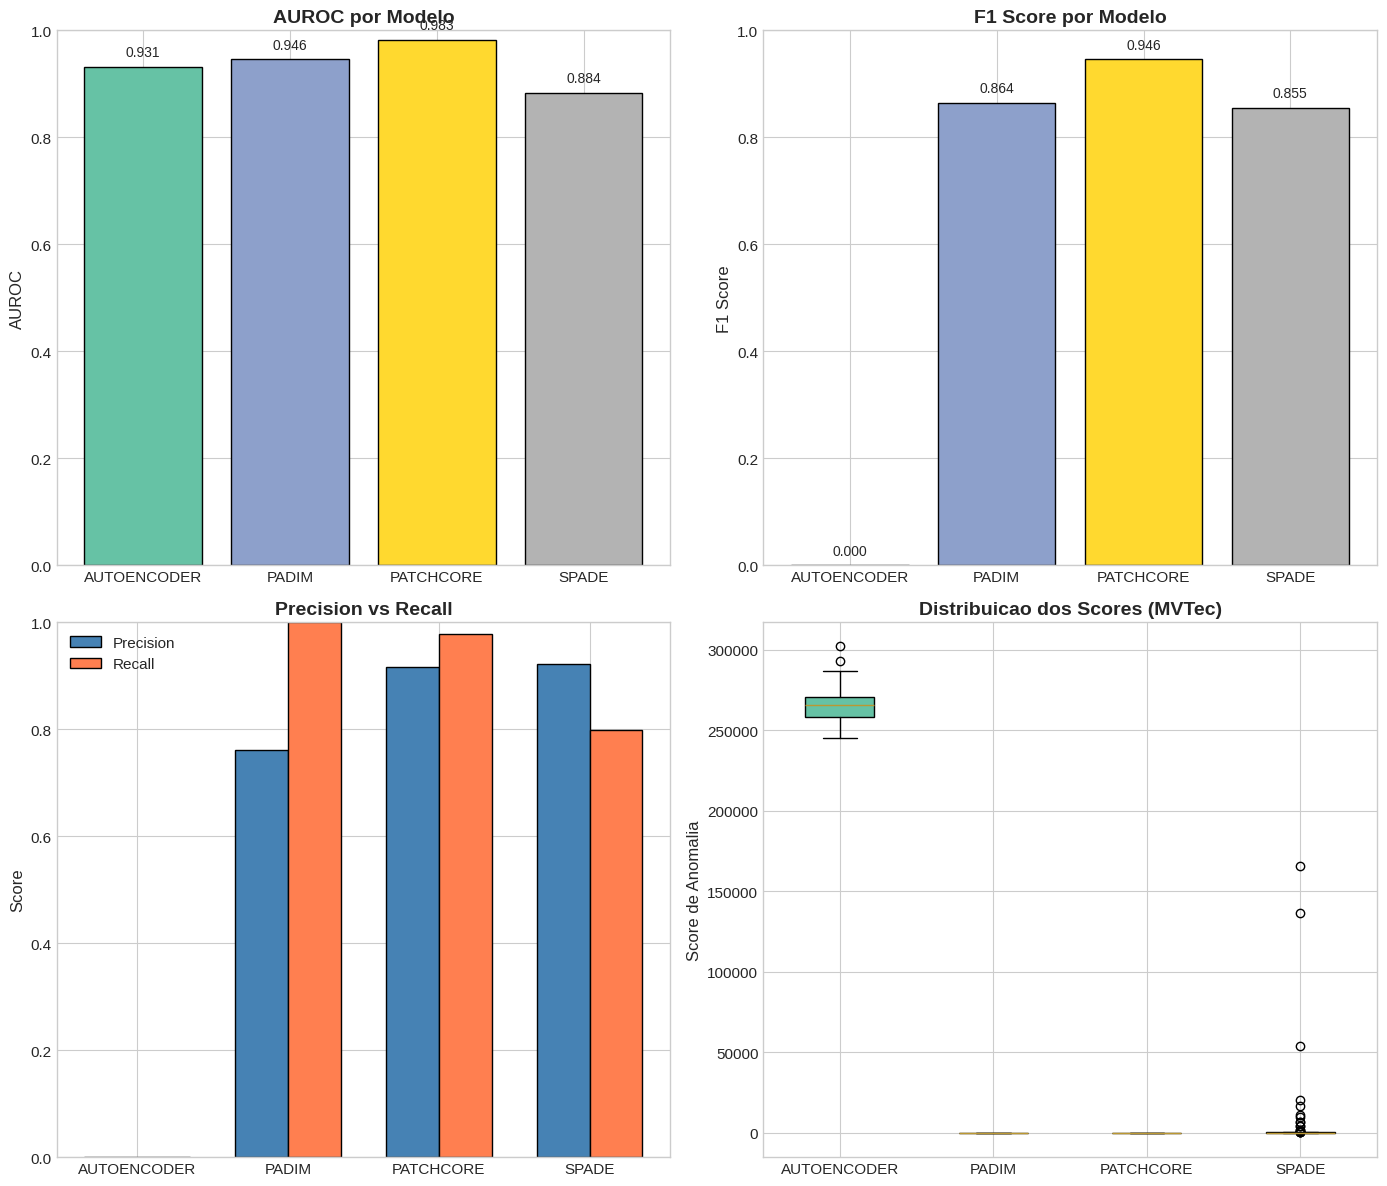


Salvo: /content/drive/MyDrive/EASE/output/model_comparison.png
Salvo: /content/drive/MyDrive/EASE/output/model_comparison.csv


In [ ]:
# ============================================================
# COMPARACAO DOS MODELOS (MVTec)
# ============================================================

print("\n" + "=" * 70)
print("COMPARACAO DOS MODELOS (MVTec Test)")
print("=" * 70)

# Criar dataframe de comparacao
comparison_data = []
for name in ['autoencoder', 'padim', 'patchcore', 'spade']:
    if name in model_results and model_results[name]:
        r = model_results[name]
        comparison_data.append({
            'Modelo': name.upper(),
            'AUROC': f"{r['auroc']:.4f}" if 'auroc' in r else 'N/A',
            'F1': f"{r['f1']:.4f}" if 'f1' in r else 'N/A',
            'Precision': f"{r['precision']:.4f}" if 'precision' in r else 'N/A',
            'Recall': f"{r['recall']:.4f}" if 'recall' in r else 'N/A',
            'AP': f"{r['ap']:.4f}" if 'ap' in r else 'N/A',
        })

df_comparison = pd.DataFrame(comparison_data)
print("\nTabela de Comparacao:")
print(df_comparison.to_string(index=False))

# Salvar
df_comparison.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)

# Visualizacao
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

if len(comparison_data) > 0:
    models_names = [m['Modelo'] for m in comparison_data]
    colors = plt.cm.Set2(np.linspace(0, 1, len(models_names)))

    # AUROC
    ax1 = axes[0, 0]
    aurocs = [float(m['AUROC']) if m['AUROC'] != 'N/A' else 0 for m in comparison_data]
    bars1 = ax1.bar(models_names, aurocs, color=colors, edgecolor='black')
    ax1.set_ylabel('AUROC')
    ax1.set_title('AUROC por Modelo', fontweight='bold')
    ax1.set_ylim(0, 1)
    for bar, val in zip(bars1, aurocs):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}',
                 ha='center', fontsize=10)

    # F1 Score
    ax2 = axes[0, 1]
    f1s = [float(m['F1']) if m['F1'] != 'N/A' else 0 for m in comparison_data]
    bars2 = ax2.bar(models_names, f1s, color=colors, edgecolor='black')
    ax2.set_ylabel('F1 Score')
    ax2.set_title('F1 Score por Modelo', fontweight='bold')
    ax2.set_ylim(0, 1)
    for bar, val in zip(bars2, f1s):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}',
                 ha='center', fontsize=10)

    # Precision vs Recall
    ax3 = axes[1, 0]
    precisions = [float(m['Precision']) if m['Precision'] != 'N/A' else 0 for m in comparison_data]
    recalls = [float(m['Recall']) if m['Recall'] != 'N/A' else 0 for m in comparison_data]

    x = np.arange(len(models_names))
    width = 0.35
    ax3.bar(x - width/2, precisions, width, label='Precision', color='steelblue', edgecolor='black')
    ax3.bar(x + width/2, recalls, width, label='Recall', color='coral', edgecolor='black')
    ax3.set_ylabel('Score')
    ax3.set_title('Precision vs Recall', fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(models_names)
    ax3.legend()
    ax3.set_ylim(0, 1)

    # Box plot dos scores
    ax4 = axes[1, 1]
    scores_list = []
    for name in ['autoencoder', 'padim', 'patchcore', 'spade']:
        if name in model_results and model_results[name]:
            scores_list.append(model_results[name]['scores'])

    if scores_list:
        bp = ax4.boxplot(scores_list, labels=models_names, patch_artist=True)
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
        ax4.set_ylabel('Score de Anomalia')
        ax4.set_title('Distribuicao dos Scores (MVTec)', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSalvo: {OUTPUT_DIR / 'model_comparison.png'}")
print(f"Salvo: {OUTPUT_DIR / 'model_comparison.csv'}")


In [ ]:
# ============================================================
# MATRIZ DE CONFUSÃO DOS MODELOS
# ============================================================

print("\n" + "=" * 70)
print("MATRIZES DE CONFUSÃO DOS MODELOS")
print("=" * 70)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(y_true, y_pred, model_name, ax):
    """Plota uma matriz de confusão estilizada."""
    cm = confusion_matrix(y_true, y_pred)
    
    # Calcular métricas
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    
    # Matriz normalizada (percentual)
    cm_percent = cm.astype('float') / cm.sum() * 100
    
    # Labels com valores absolutos e percentuais
    labels = np.array([
        [f'TN\n{tn}\n({cm_percent[0,0]:.1f}%)', f'FP\n{fp}\n({cm_percent[0,1]:.1f}%)'],
        [f'FN\n{fn}\n({cm_percent[1,0]:.1f}%)', f'TP\n{tp}\n({cm_percent[1,1]:.1f}%)']
    ])
    
    # Plotar heatmap
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', 
                xticklabels=['Normal', 'Anomalia'],
                yticklabels=['Normal', 'Anomalia'],
                ax=ax, cbar=True, square=True,
                annot_kws={'size': 12, 'weight': 'bold'})
    
    ax.set_xlabel('Predito', fontsize=12, fontweight='bold')
    ax.set_ylabel('Real', fontsize=12, fontweight='bold')
    ax.set_title(f'Matriz de Confusão - {model_name.upper()}', fontsize=14, fontweight='bold')
    
    return cm, tn, fp, fn, tp

# Coletar dados de todos os modelos disponíveis
models_with_data = []
for name in ['autoencoder', 'padim', 'patchcore', 'spade']:
    if name in model_results and model_results[name]:
        if 'predictions' in model_results[name] and 'labels' in model_results[name]:
            models_with_data.append(name)

if len(models_with_data) > 0:
    # Criar subplots para cada modelo
    n_models = len(models_with_data)
    n_cols = min(2, n_models)
    n_rows = (n_models + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 6*n_rows))
    if n_models == 1:
        axes = np.array([axes])
    axes = axes.flatten() if n_models > 1 else [axes]
    
    # Criar tabela de métricas
    metrics_data = []
    
    for idx, name in enumerate(models_with_data):
        r = model_results[name]
        y_true = np.array(r['labels'])
        y_pred = np.array(r['predictions'])
        
        # Plotar matriz de confusão
        cm, tn, fp, fn, tp = plot_confusion_matrix(y_true, y_pred, name, axes[idx])
        
        # Calcular métricas detalhadas
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        metrics_data.append({
            'Modelo': name.upper(),
            'TP': tp,
            'TN': tn,
            'FP': fp,
            'FN': fn,
            'Accuracy': f'{accuracy:.2%}',
            'Precision': f'{precision:.2%}',
            'Recall': f'{recall:.2%}',
            'Specificity': f'{specificity:.2%}',
            'F1-Score': f'{f1:.2%}'
        })
    
    # Esconder eixos extras
    for idx in range(len(models_with_data), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Exibir tabela de métricas
    print("\n" + "=" * 100)
    print("MÉTRICAS DERIVADAS DAS MATRIZES DE CONFUSÃO")
    print("=" * 100)
    
    df_metrics = pd.DataFrame(metrics_data)
    print(df_metrics.to_string(index=False))
    
    # Salvar métricas
    df_metrics.to_csv(OUTPUT_DIR / 'confusion_matrix_metrics.csv', index=False)
    print(f"\nSalvo: {OUTPUT_DIR / 'confusion_matrices.png'}")
    print(f"Salvo: {OUTPUT_DIR / 'confusion_matrix_metrics.csv'}")
    
    # Legenda
    print("\n" + "-" * 70)
    print("LEGENDA:")
    print("  TP (True Positive)  = Anomalia real detectada corretamente")
    print("  TN (True Negative)  = Normal real classificado corretamente")
    print("  FP (False Positive) = Normal classificado como anomalia (Falso Alarme)")
    print("  FN (False Negative) = Anomalia não detectada (Miss)")
    print("  Precision = TP/(TP+FP) - Dos detectados como anomalia, quantos são reais")
    print("  Recall    = TP/(TP+FN) - Das anomalias reais, quantas foram detectadas")
    print("  Specificity = TN/(TN+FP) - Dos normais reais, quantos foram classificados corretamente")
    print("-" * 70)
else:
    print("❌ Nenhum modelo com dados de labels e predictions encontrado.")
    print("   Execute os modelos com dados de teste MVTec primeiro.")

print("=" * 70)


In [ ]:
# ============================================================
# RANKING DE IMAGENS DO CLIENTE POR SCORE DE ANOMALIA
# ============================================================

print("\n" + "=" * 70)
print("RANKING DE IMAGENS DO CLIENTE (Por Score de Anomalia)")
print("=" * 70)
print("   Analise qualitativa: imagens com maior score = mais provaveis de ter anomalias")

# Coletar scores de todos os modelos
all_scores = {}
for name in ['autoencoder', 'padim', 'patchcore', 'spade']:
    key = f'{name}_client'
    if key in model_results and model_results[key]:
        all_scores[name] = {
            'scores': model_results[key]['scores'],
            'predictions': model_results[key]['predictions'],
        }

# Criar DataFrame com ranking
if all_scores and client_names:
    ranking_data = []

    for i, (name, scores_dict) in enumerate(all_scores.items()):
        for j, score in enumerate(scores_dict['scores']):
            if i == 0:  # Primeiro modelo
                ranking_data.append({
                    'filename': client_names[j] if j < len(client_names) else f'image_{j}',
                    f'{name}_score': score,
                    f'{name}_pred': 'ANOMALIA' if scores_dict['predictions'][j] == 1 else 'NORMAL',
                })
            else:
                ranking_data[j][f'{name}_score'] = score
                ranking_data[j][f'{name}_pred'] = 'ANOMALIA' if scores_dict['predictions'][j] == 1 else 'NORMAL'

    df_ranking = pd.DataFrame(ranking_data)

    # Calcular score medio
    score_cols = [c for c in df_ranking.columns if '_score' in c]
    df_ranking['score_medio'] = df_ranking[score_cols].mean(axis=1)

    # Ordenar por score medio
    df_ranking = df_ranking.sort_values('score_medio', ascending=False)

    # Salvar
    df_ranking.to_csv(OUTPUT_DIR / 'client_ranking.csv', index=False)

    # Exibir top 15
    print("\nTOP 15 IMAGENS COM MAIOR SCORE DE ANOMALIA:")
    print("-" * 100)

    display_cols = ['filename', 'score_medio'] + score_cols
    print(df_ranking[display_cols].head(15).to_string(index=False))

    # Contagem de anomalias por modelo
    print("\n" + "-" * 70)
    print("RESUMO DE DETECCOES POR MODELO:")
    print("-" * 70)
    for name in ['autoencoder', 'padim', 'patchcore', 'spade']:
        if f'{name}_client' in all_scores:
            pred_col = f'{name}_pred'
            if pred_col in df_ranking.columns:
                n_anomaly = (df_ranking[pred_col] == 'ANOMALIA').sum()
                print(f"  {name.upper():15}: {n_anomaly} anomalias detectadas ({100*n_anomaly/len(df_ranking):.1f}%)")

    print(f"\nRanking completo salvo em: {OUTPUT_DIR / 'client_ranking.csv'}")

print("=" * 70)



RANKING DE IMAGENS DO CLIENTE (Por Score de Anomalia)
   Analise qualitativa: imagens com maior score = mais provaveis de ter anomalias

TOP 15 IMAGENS COM MAIOR SCORE DE ANOMALIA:
----------------------------------------------------------------------------------------------------
                                                                   filename   score_medio  autoencoder_score  padim_score  patchcore_score  spade_score
             Dimensional - Entrepernas assimetrico - lavado_func2_rot45.jpg 858755.929195        814580.5000    43.272024        56.194756   2620343.75
             Dimensional - Entrepernas assimetrico - lavado_func2_rot15.jpg 855662.827579        689036.8750    57.653198        55.782120   2733501.00
  Dimensional - Entrepernas assimetrico - lavado_func3_shear_x0.05_y0.0.jpg 818396.729512        584163.5625    46.488891        52.616657   2689324.25
             Dimensional - Entrepernas assimetrico - lavado_func2_rot-5.jpg 801348.237239        608385.9375 


VISUALIZACAO: IMAGENS DO CLIENTE POR SCORE DE ANOMALIA


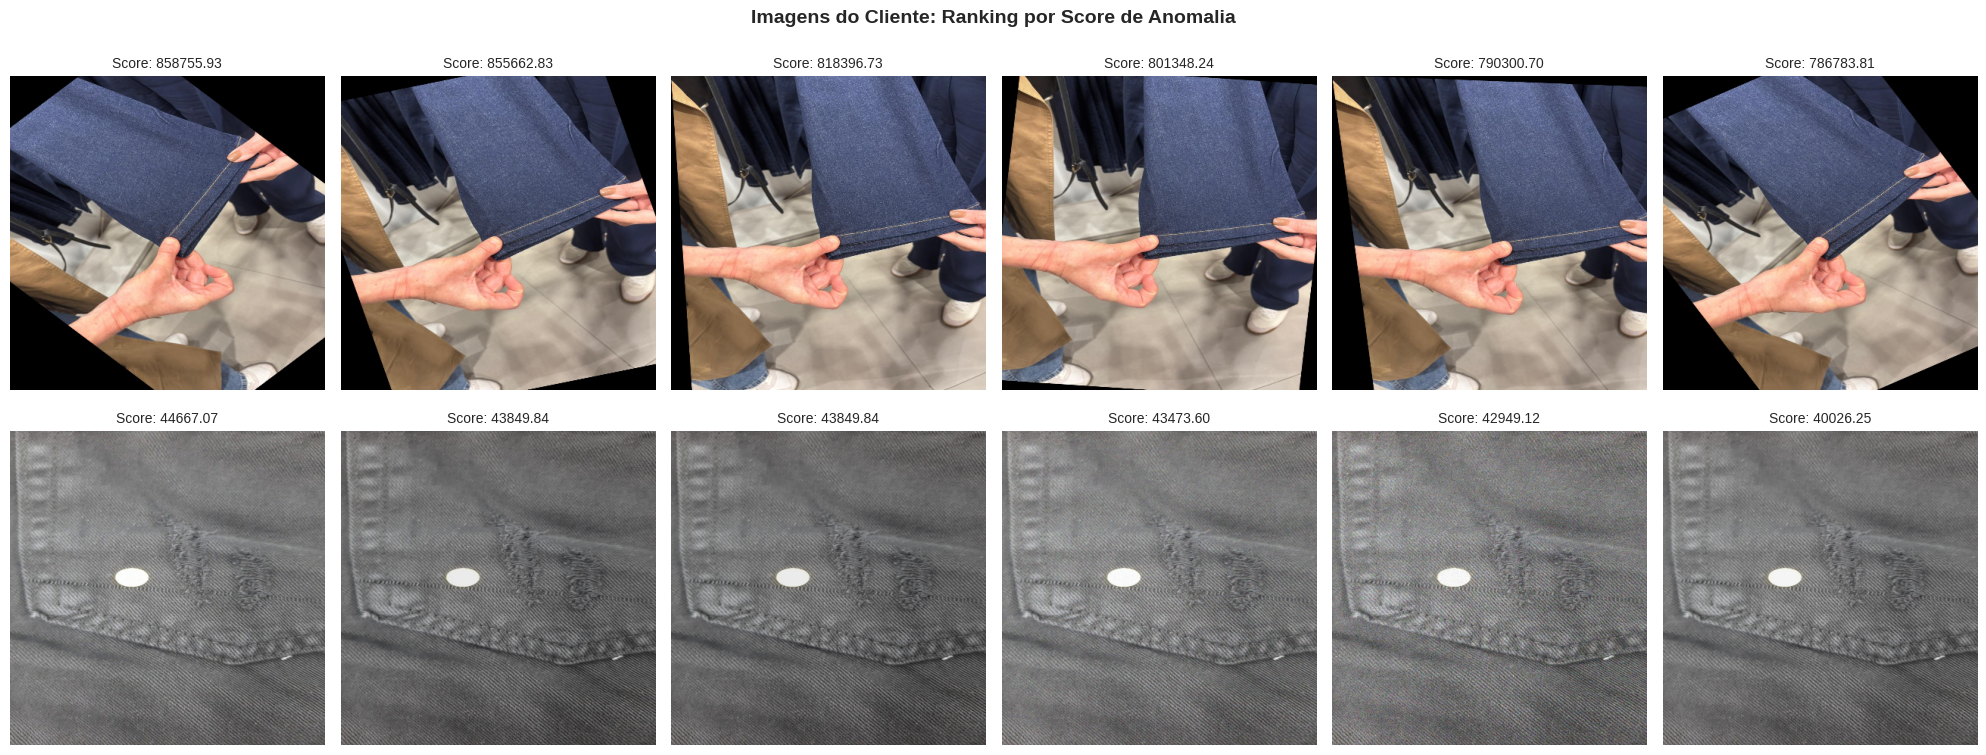

Salvo: /content/drive/MyDrive/EASE/output/client_ranking_visualization.png


In [ ]:
# ============================================================
# VISUALIZACAO DAS IMAGENS DO CLIENTE POR SCORE
# ============================================================

print("\n" + "=" * 70)
print("VISUALIZACAO: IMAGENS DO CLIENTE POR SCORE DE ANOMALIA")
print("=" * 70)

if len(client_images) > 0 and 'score_medio' in df_ranking.columns:
    # Pegar as imagens mais anormais e mais normais
    df_sorted = df_ranking.reset_index(drop=True)

    # Top 6 mais anormais
    top_anomaly = df_sorted.head(6)

    # Top 6 mais normais
    top_normal = df_sorted.tail(6)

    fig, axes = plt.subplots(2, 6, figsize=(20, 8))

    # Linha 1: Mais anormais
    for i, (_, row) in enumerate(top_anomaly.iterrows()):
        idx = client_names.index(row['filename']) if row['filename'] in client_names else i
        if idx < len(client_images):
            axes[0, i].imshow(client_images[idx])
            axes[0, i].set_title(f"Score: {row['score_medio']:.2f}", fontsize=10)
            axes[0, i].axis('off')
    axes[0, 0].set_ylabel('MAIS ANORMAIS', fontsize=12, fontweight='bold')

    # Linha 2: Mais normais
    for i, (_, row) in enumerate(top_normal.iterrows()):
        idx = client_names.index(row['filename']) if row['filename'] in client_names else i
        if idx < len(client_images):
            axes[1, i].imshow(client_images[idx])
            axes[1, i].set_title(f"Score: {row['score_medio']:.2f}", fontsize=10)
            axes[1, i].axis('off')
    axes[1, 0].set_ylabel('MAIS NORMAIS', fontsize=12, fontweight='bold')

    plt.suptitle('Imagens do Cliente: Ranking por Score de Anomalia', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'client_ranking_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Salvo: {OUTPUT_DIR / 'client_ranking_visualization.png'}")

print("=" * 70)



ANALISE DE CONCORDANCIA ENTRE MODELOS (CLIENTE)


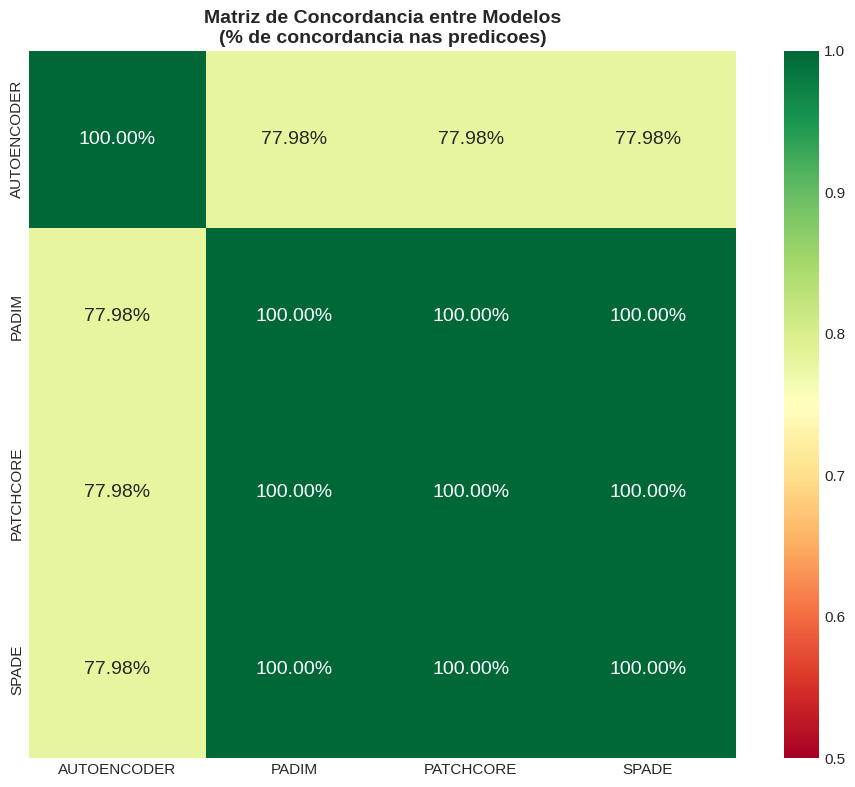


Interpretacao:
   - Valores altos (verde): modelos concordam nas predicoes
   - Valores baixos (vermelho): modelos discordam

Salvo: /content/drive/MyDrive/EASE/output/model_agreement.png


In [ ]:
# ============================================================
# ANALISE DE CONCORDANCIA ENTRE MODELOS
# ============================================================

print("\n" + "=" * 70)
print("ANALISE DE CONCORDANCIA ENTRE MODELOS (CLIENTE)")
print("=" * 70)

if all_scores:
    # Matriz de concordancia
    model_names = list(all_scores.keys())
    n_models = len(model_names)

    agreement_matrix = np.zeros((n_models, n_models))

    for i, name1 in enumerate(model_names):
        for j, name2 in enumerate(model_names):
            pred1 = all_scores[name1]['predictions']
            pred2 = all_scores[name2]['predictions']
            agreement = np.mean(pred1 == pred2)
            agreement_matrix[i, j] = agreement

    # Visualizacao
    fig, ax = plt.subplots(figsize=(10, 8))

    model_labels = [m.upper() for m in model_names]

    sns.heatmap(agreement_matrix, annot=True, fmt='.2%', cmap='RdYlGn',
                xticklabels=model_labels, yticklabels=model_labels,
                ax=ax, vmin=0.5, vmax=1.0, square=True,
                annot_kws={'size': 14})

    ax.set_title('Matriz de Concordancia entre Modelos\n(% de concordancia nas predicoes)',
                 fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'model_agreement.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nInterpretacao:")
    print("   - Valores altos (verde): modelos concordam nas predicoes")
    print("   - Valores baixos (vermelho): modelos discordam")
    print(f"\nSalvo: {OUTPUT_DIR / 'model_agreement.png'}")

print("=" * 70)


# FASE 6: DEPLOYMENT

Relatorio Final e Salvamento dos Resultados

---


In [ ]:
# ============================================================
# SALVAMENTO DOS MODELOS
# ============================================================

print("\n" + "=" * 70)
print("SALVANDO MODELOS E RESULTADOS")
print("=" * 70)

for name, model in models.items():
    if model is not None:
        model_path = OUTPUT_DIR / f'{name}_model.pkl'
        model.save(model_path)
        print(f"  Salvo: {model_path}")

print("=" * 70)



SALVANDO MODELOS E RESULTADOS
  Salvo: /content/drive/MyDrive/EASE/output/autoencoder_model.pkl
  Salvo: /content/drive/MyDrive/EASE/output/padim_model.pkl
  Salvo: /content/drive/MyDrive/EASE/output/patchcore_model.pkl
  Salvo: /content/drive/MyDrive/EASE/output/spade_model.pkl


In [ ]:
# ============================================================
# RELATORIO FINAL DA PoC
# ============================================================

print("\n" + "=" * 70)
print("RELATORIO FINAL DA PoC")
print("=" * 70)

# Coletar metricas
summary_data = []
for name in ['autoencoder', 'padim', 'patchcore', 'spade']:
    if name in model_results and model_results[name]:
        r = model_results[name]
        summary_data.append({
            'modelo': name.upper(),
            'auroc': r.get('auroc', 'N/A'),
            'f1': r.get('f1', 'N/A'),
            'recall': r.get('recall', 'N/A'),
            'precision': r.get('precision', 'N/A'),
        })

print(f"""
+---------------------------------------------------------------------+
|                  RESUMO EXECUTIVO DA PoC                          |
+---------------------------------------------------------------------+
|                                                                     |
|  OBJETIVO: Validar viabilidade tecnica da deteccao de anomalias    |
|              no contexto real do cliente.                          |
|                                                                     |
|  ESTRATEGIA: Multiplas arquiteturas para comparacao                |
|                                                                     |
+---------------------------------------------------------------------+
|  MODELOS IMPLEMENTADOS:                                            |
|  ---------------------------------------------------------------    |
|  1. Autoencoder: Baseline de reconstrucao                          |
|  2. PaDiM: Patch Distribution Modeling (Gaussianas)                |
|  3. PatchCore: Memory bank + KNN                                   |
|  4. SPADE: Piramide semantica multi-escala                         |
|                                                                     |
+---------------------------------------------------------------------+
|  AVALIACAO TECNICA (MVTec Carpet)                                  |
|  ---------------------------------------------------------------    |
""")

for data in summary_data:
    auroc = data['auroc'] if isinstance(data['auroc'], str) else f"{data['auroc']:.4f}"
    print(f"|  {data['modelo']:12} | AUROC: {auroc}                          |")

print(f"""                                                                     |
+---------------------------------------------------------------------+
|  AVALIACAO FINAL (Imagens do Cliente)                              |
|  Total de imagens analisadas: {len(client_images)}                             |
|  Metrica: Ranking por score de anomalia                            |
|                                                                     |
|  ATENCAO: Imagens do cliente foram usadas APENAS para validacao!   |
|                                                                     |
+---------------------------------------------------------------------+
|  ARQUIVOS GERADOS:                                                 |
|  ---------------------------------------------------------------    |
|  - Modelos salvos: *_model.pkl                                     |
|  - client_ranking.csv: Ranking das imagens do cliente              |
|  - model_comparison.csv: Comparacao dos modelos (MVTec)            |
|  - Visualizacoes: *.png                                            |
|                                                                     |
+---------------------------------------------------------------------+
""")

print("\nARQUIVOS GERADOS:")
for f in sorted(OUTPUT_DIR.glob('*')):
    print(f"  - {f.name}")

print("\n" + "=" * 70)
print("POC CONCLUIDA COM SUCESSO!")
print("=" * 70)



RELATORIO FINAL DA PoC

+---------------------------------------------------------------------+
|                  RESUMO EXECUTIVO DA PoC                          |
+---------------------------------------------------------------------+
|                                                                     |
|  OBJETIVO: Validar viabilidade tecnica da deteccao de anomalias    |
|              no contexto real do cliente.                          |
|                                                                     |
|  ESTRATEGIA: Multiplas arquiteturas para comparacao                |
|                                                                     |
+---------------------------------------------------------------------+
|  MODELOS IMPLEMENTADOS:                                            |
|  ---------------------------------------------------------------    |
|  1. Autoencoder: Baseline de reconstrucao                          |
|  2. PaDiM: Patch Distribution Modeling (Gaus

## Conclusoes e Proximos Passos

### Resumo dos Resultados

Este notebook implementou um sistema avancado de deteccao de anomalias em tecidos, comparando quatro arquiteturas state-of-the-art:

1. **Autoencoder**: Abordagem classica de reconstrucao
2. **PaDiM**: Modelagem estatistica das distribuicoes de patches
3. **PatchCore**: Memory bank eficiente com KNN
4. **SPADE**: Piramide semantica multi-escala

### Estrategia de Validacao

**PRINCIPIO FUNDAMENTAL:** As imagens fornecidas pelo cliente foram usadas APENAS para validacao final da PoC, garantindo que:
- Os resultados refletem o desempenho real em producao
- Nao ha overfitting aos dados especificos do cliente
- A PoC representa valor real para o negocio

### Interpretacao dos Resultados

**Para dados do cliente:**
- Nao utilizamos metricas de acuracia tradicionais
- Analisamos o ranking das imagens por score de anomalia
- Imagens com alto score devem ser inspecionadas manualmente
- Alta concordancia entre modelos aumenta a confianca

### Proximos Passos Recomendados

1. **Coleta de Dados Anotados**: Obter imagens rotuladas do cliente para fine-tuning
2. **Fine-tuning Supervisionado**: Adaptar o melhor modelo aos dados do cliente
3. **Classificacao Multi-classe**: Identificar o tipo especifico de defeito
4. **Deploy em Producao**: Exportar modelo otimizado (ONNX/TensorRT)
5. **Interface de Visualizacao**: Ferramenta para inspecao das deteccoes

---


